<a href="https://colab.research.google.com/github/iyashh/Time_Series/blob/main/Stock_Market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torchviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
!pip install torch-summary
!pip install yfinance

In [9]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
import yfinance as yf
import torch.optim as optim
import torch.functional as F
from torchviz import make_dot
from tqdm.notebook import tqdm
from datetime import timedelta
import matplotlib.pyplot as plt
from torchsummary import summary
from IPython.display import Image
import plotly.graph_objects as go
from keras.utils import plot_model
from keras.models import Sequential
from IPython.display import Image, display
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, Dense, Dropout

In [1]:
!pip install yfinance --upgrade  # Upgrade yfinance to the latest version
import yfinance as yf
import time

tck = yf.Ticker("GOOG")
start_date = "2016-06-14"

try:
    df = tck.history(start=start_date, end=None)
except Exception as e:  # Catch a broader range of exceptions
    if 'YFRateLimitError' in str(e):  # Check if it's a rate limit error
        print("Rate limited. Waiting 60 seconds...")
        time.sleep(60)  # Wait for 60 seconds before retrying
        df = tck.history(start=start_date, end=None)  # Retry the request
    else:
        raise e  # Re-raise other exceptions

df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-06-14 00:00:00-04:00,35.655119,35.953207,35.487908,35.744198,26122000,0.0,0.0
2016-06-15 00:00:00-04:00,35.780529,35.978589,35.696428,35.776546,24290000,0.0,0.0
2016-06-16 00:00:00-04:00,35.576988,35.663579,34.997233,35.350563,39650000,0.0,0.0
2016-06-17 00:00:00-04:00,35.265464,35.273927,34.260326,34.422955,68048000,0.0,0.0
2016-06-20 00:00:00-04:00,34.773794,34.958420,34.507059,34.521988,41650000,0.0,0.0
...,...,...,...,...,...,...,...
2025-05-01 00:00:00-04:00,162.520004,163.940002,160.929993,162.789993,21904300,0.0,0.0
2025-05-02 00:00:00-04:00,164.955002,166.699997,163.660004,165.809998,16844900,0.0,0.0
2025-05-05 00:00:00-04:00,164.514999,167.100006,164.470001,166.050003,15309300,0.0,0.0


In [2]:
# Move column 'Close' to the first position
col_close = df.pop('Close')
df.insert(0, 'Close', col_close)
df.head()

,Close,Open,High,Low,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-06-14 00:00:00-04:00,35.744198,35.655119,35.953207,35.487908,26122000,0.0,0.0
2016-06-15 00:00:00-04:00,35.776546,35.780529,35.978589,35.696428,24290000,0.0,0.0
2016-06-16 00:00:00-04:00,35.350563,35.576988,35.663579,34.997233,39650000,0.0,0.0
2016-06-17 00:00:00-04:00,34.422955,35.265464,35.273927,34.260326,68048000,0.0,0.0
2016-06-20 00:00:00-04:00,34.521988,34.773794,34.958420,34.507059,41650000,0.0,0.0


In [3]:
df.columns

Index(['Close', 'Open', 'High', 'Low', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [4]:
df.shape

(2238, 7)

In [5]:
def check_df(df: object, head: object = 5) -> object:
    print("\nShape")
    print(df.shape)
    print("\nTypes")
    print(df.dtypes)
    print("\nNANs")
    print(df.isnull().sum())
    print("\nInfo")
    print(df.info())
check_df(df)


Shape
(2238, 7)

Types
Close           float64
Open            float64
High            float64
Low             float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

NANs
Close           0
Open            0
High            0
Low             0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Info
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2238 entries, 2016-06-14 00:00:00-04:00 to 2025-05-07 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         2238 non-null   float64
 1   Open          2238 non-null   float64
 2   High          2238 non-null   float64
 3   Low           2238 non-null   float64
 4   Volume        2238 non-null   int64  
 5   Dividends     2238 non-null   float64
 6   Stock Splits  2238 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 139.9 KB
None


In [6]:
df['Volume'] = df['Volume'].astype('float64')

In [7]:
print('Number of duplicated rows: ' , len(df[df.duplicated()]))

Number of duplicated rows:  0


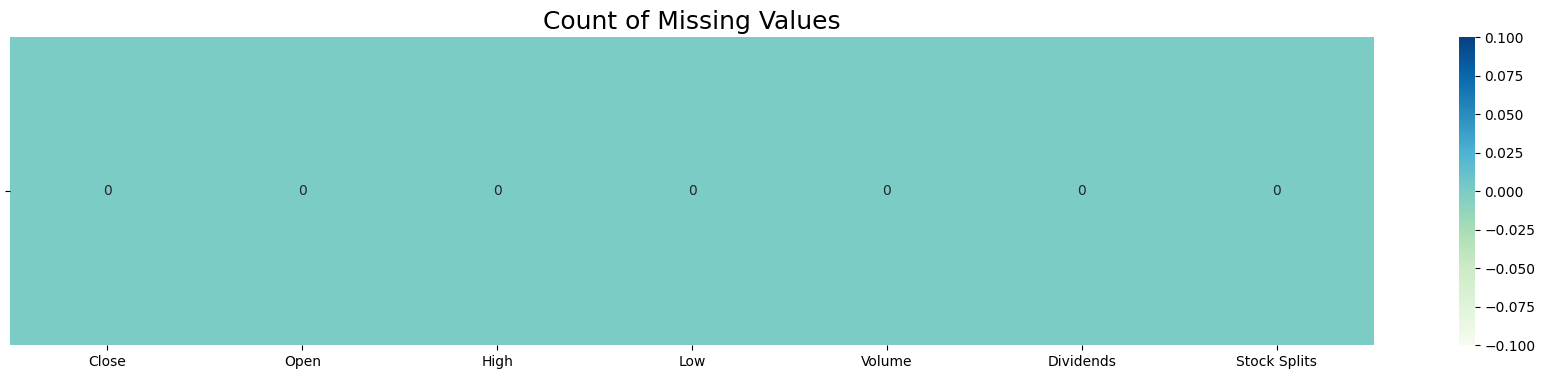

In [10]:
plt.figure(figsize=(22,4))
sns.heatmap((df.isna().sum()).to_frame(name='').T,cmap='GnBu', annot=True,
             fmt='0.0f').set_title('Count of Missing Values', fontsize=18)
plt.show()

In [11]:
df.describe().T.style.background_gradient(cmap='GnBu', axis=1)

,count,mean,std,min,25%,50%,75%,max
Close,2238.000000,94.238572,44.698551,33.255486,54.866129,86.545574,132.832848,207.473633
Open,2238.000000,94.178764,44.691515,33.391841,54.890759,86.351507,132.721617,204.267279
High,2238.000000,95.215784,45.210115,33.456537,55.416120,87.574714,134.120123,208.462496
Low,2238.000000,93.230998,44.209394,33.007860,54.305283,85.638629,131.490961,204.027547
Volume,2238.000000,28583332.695710,13186195.508579,1100573.000000,20065900.000000,25563650.000000,32952500.000000,124140000.000000
Dividends,2238.000000,0.000357,0.008450,0.000000,0.000000,0.000000,0.000000,0.200000
Stock Splits,2238.000000,0.008937,0.422766,0.000000,0.000000,0.000000,0.000000,20.000000


In [12]:
# finding unique data
df.apply(lambda x: len(x.unique()))

,0
Close,2204
Open,2238
High,2238
Low,2238
Volume,2170
Dividends,2
Stock Splits,2


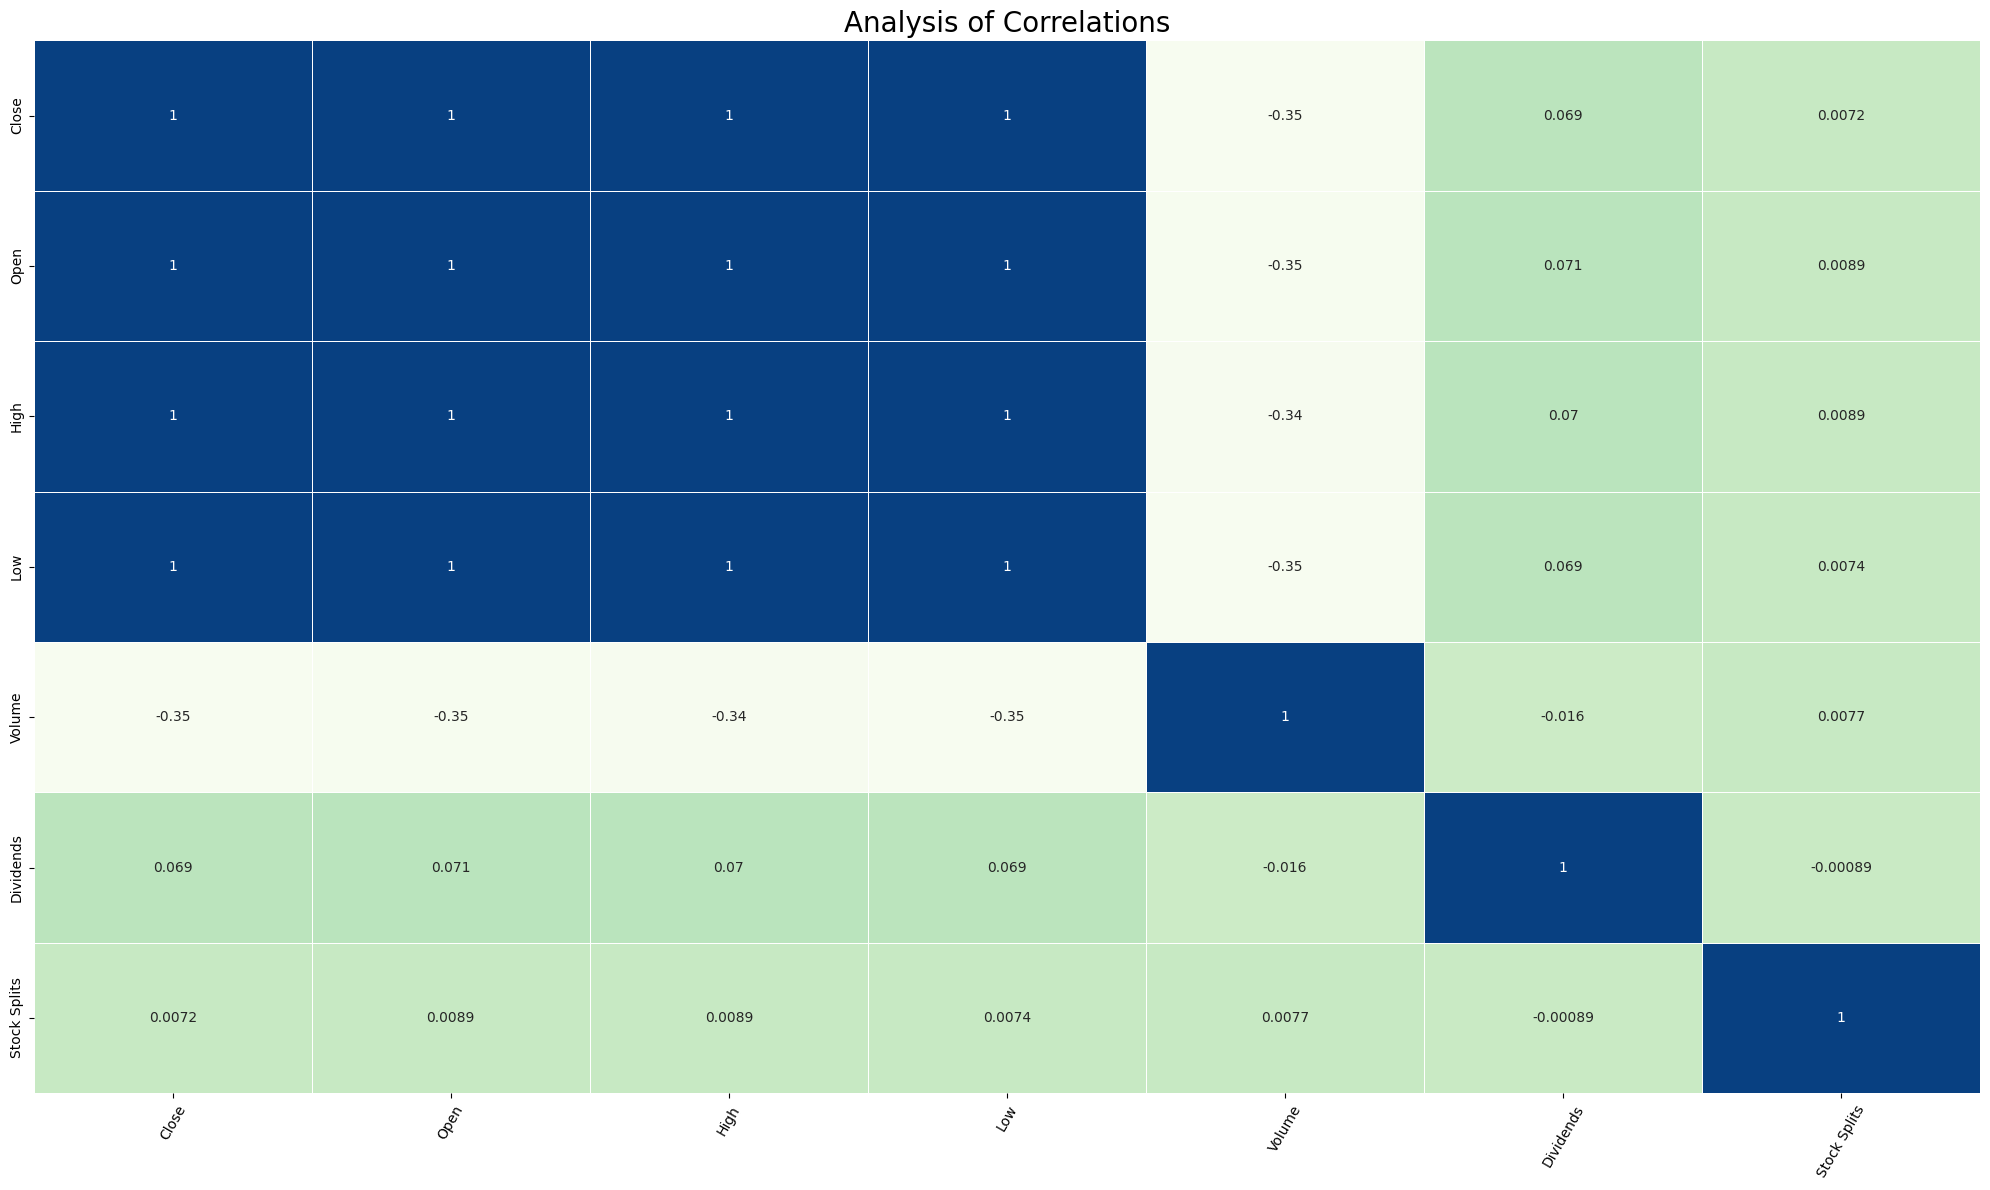

In [13]:
plt.figure(figsize=(20, 12))
sns.heatmap(df.corr(numeric_only=True), cmap="GnBu", annot=True, linewidths=.6 , cbar = False)
plt.xticks(rotation=60, size=10)
plt.yticks(size=10)
plt.title('Analysis of Correlations', size=20)
plt.tight_layout()
plt.show()

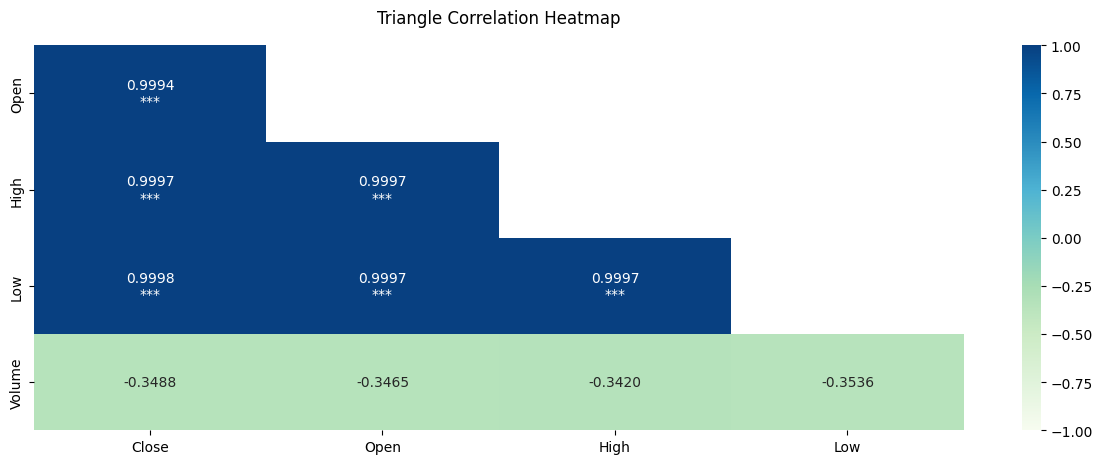

In [14]:
corr = df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(15, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
cut_off = 0.25
extreme_1 = 0.5
extreme_2 = 0.75
extreme_3 = 0.9
mask |= np.abs(corr) < cut_off
corr = corr[~mask]
remove_empty_rows_and_cols = True
if remove_empty_rows_and_cols:
    wanted_cols = np.flatnonzero(np.count_nonzero(~mask, axis=1))
    wanted_rows = np.flatnonzero(np.count_nonzero(~mask, axis=0))
    corr = corr.iloc[wanted_cols, wanted_rows]

annot = [[f"{val:.4f}"
          + ('' if abs(val) < extreme_1 else '\n*')
          + ('' if abs(val) < extreme_2 else '*')
          + ('' if abs(val) < extreme_3 else '*')
          for val in row] for row in corr.to_numpy()]
heatmap = sns.heatmap(corr, vmin=-1, vmax=1, annot=annot, fmt='', cmap='GnBu')
heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize': 12}, pad=16)
plt.show()

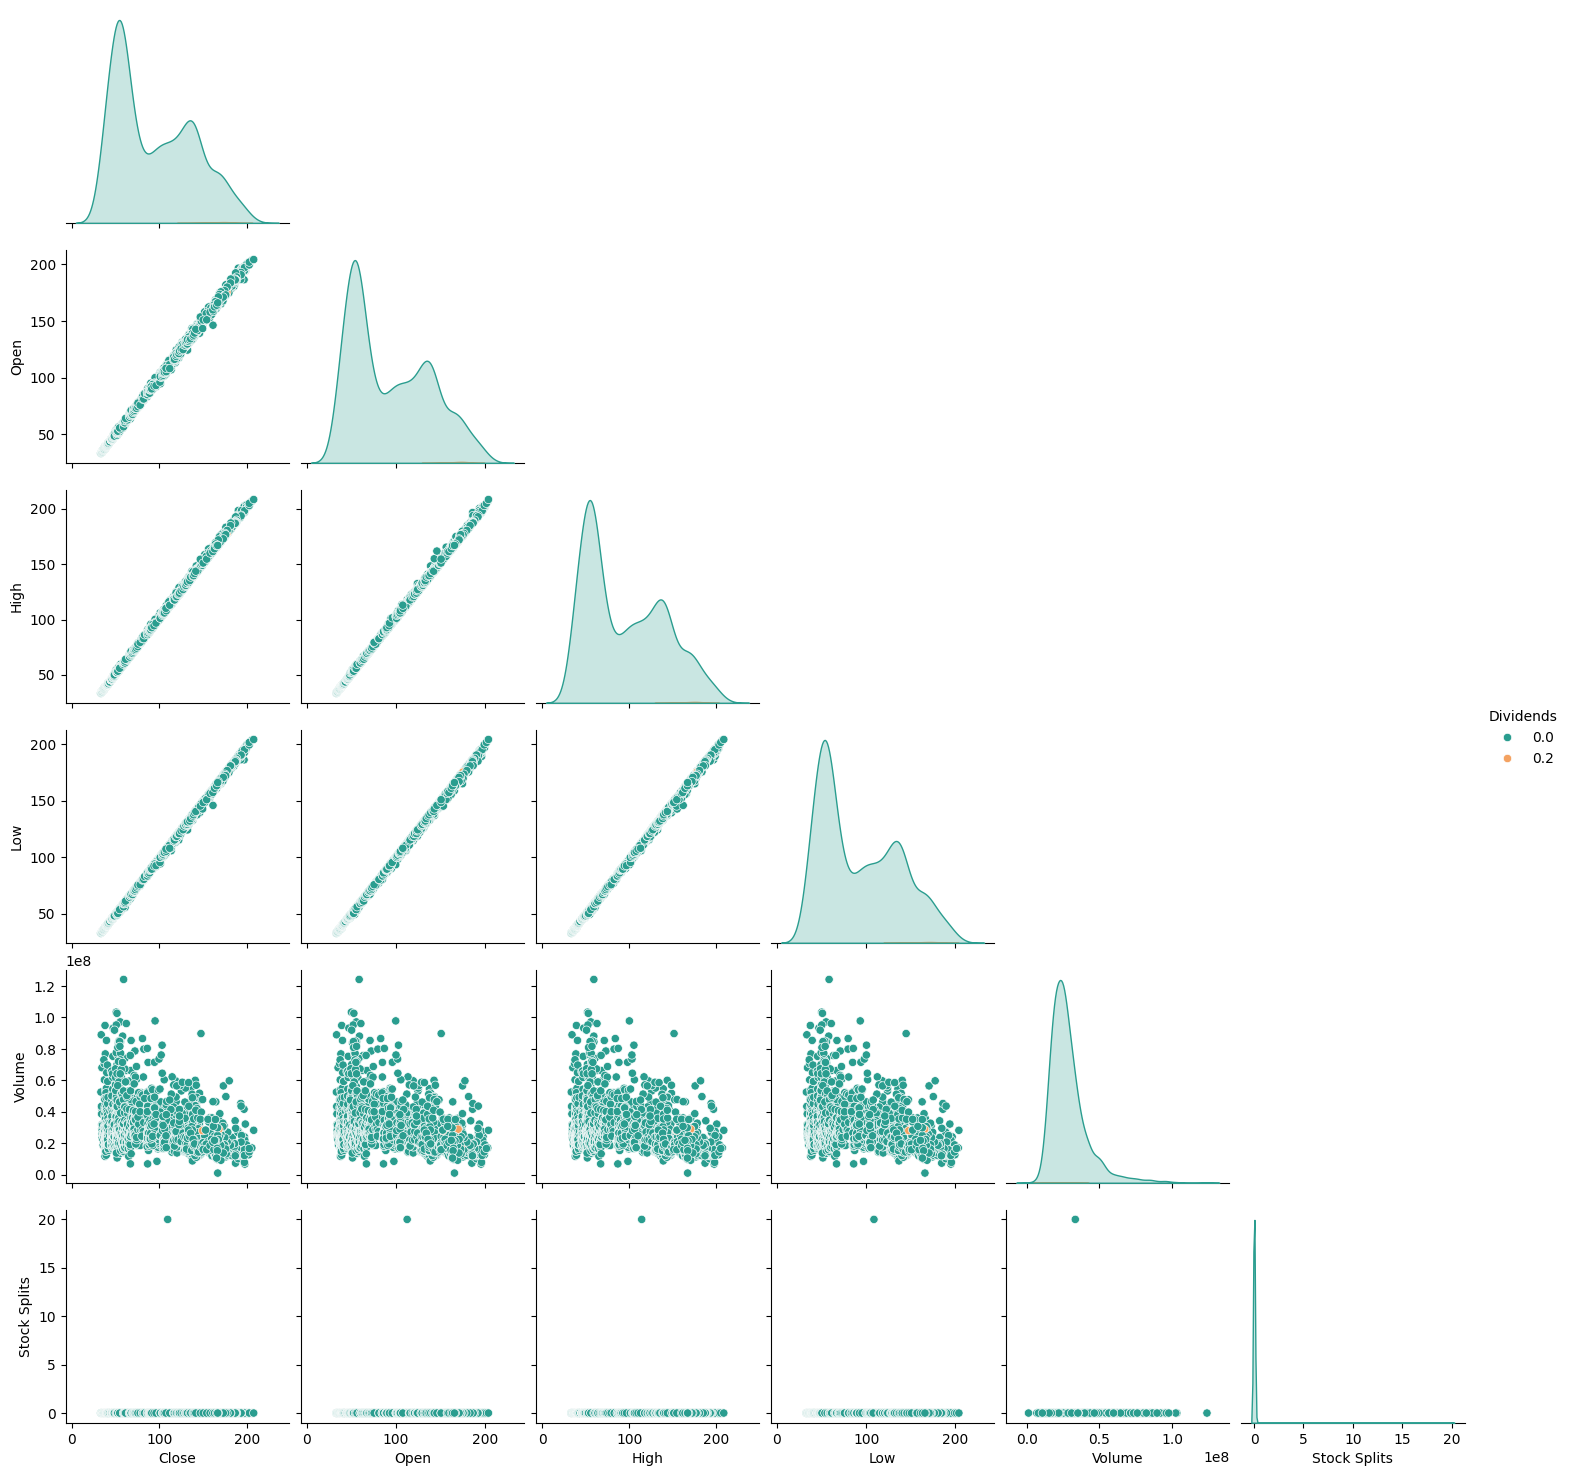

In [15]:
import warnings
warnings.filterwarnings('ignore')
custom_palette = sns.color_palette(['#2a9d8f', '#f4a261'])
sns.pairplot(data=df, diag_kind='kde', hue='Dividends', palette=custom_palette,corner=True)
plt.gcf().set_facecolor('#ffffff')
plt.show()

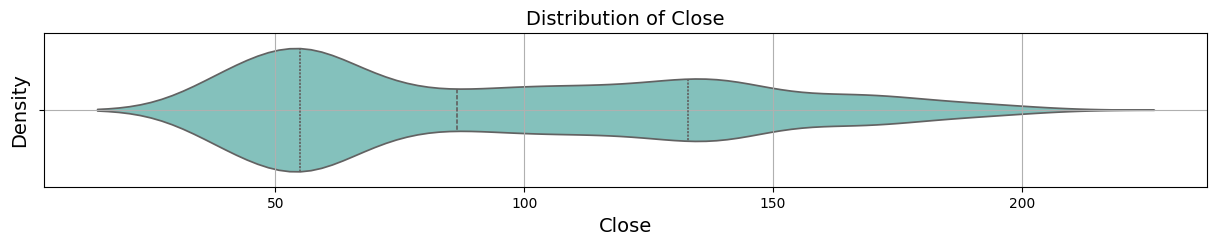

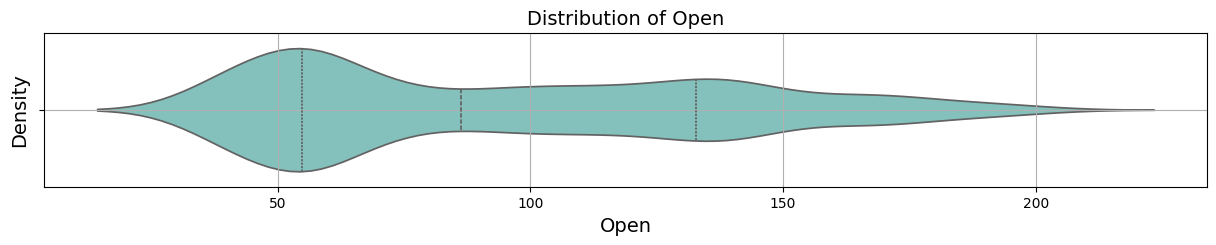

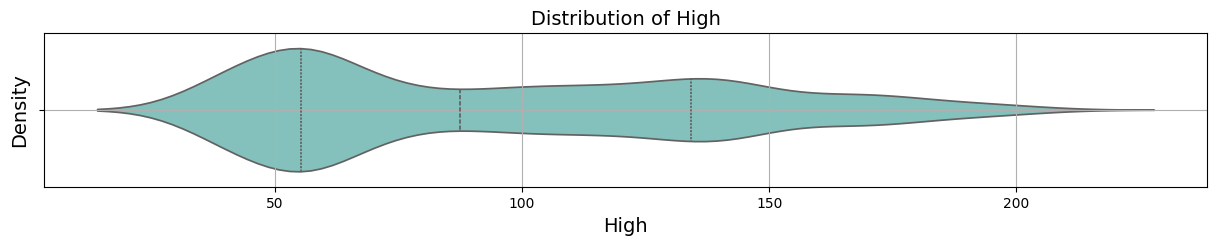

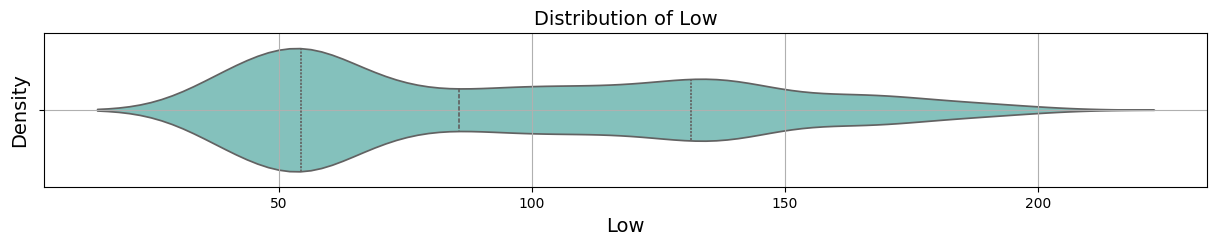

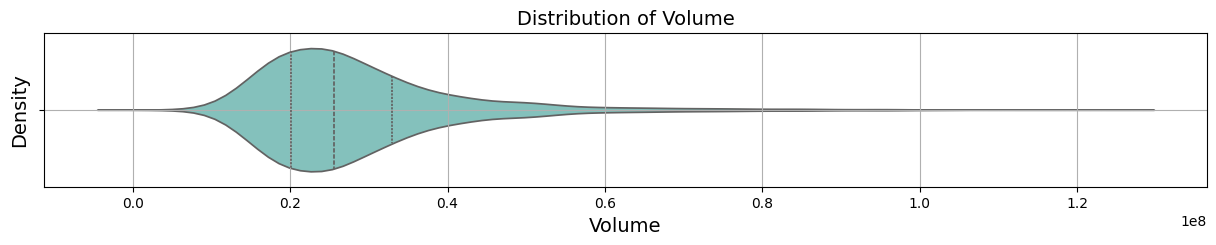

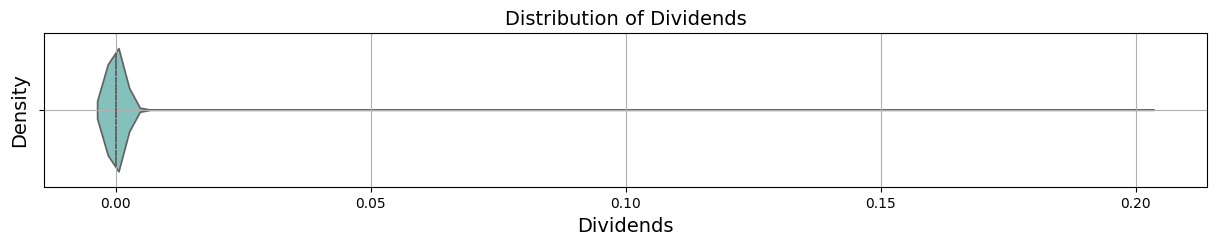

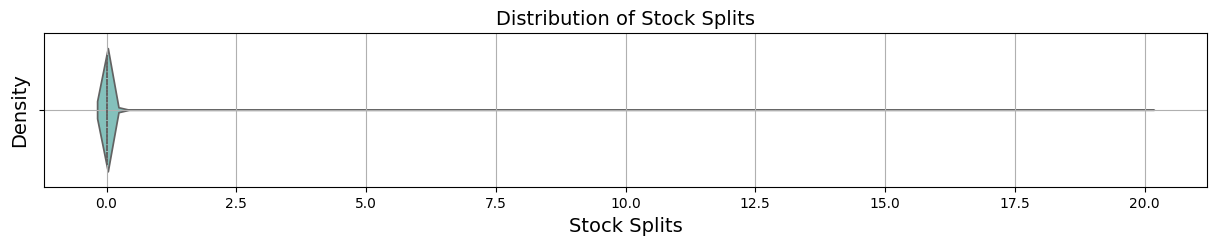

In [17]:
palette = "GnBu"
for column in df.columns: # Change 'columns' to 'df.columns'
    plt.figure(figsize=(15, 2))
    sns.violinplot(x=df[column], palette=palette, inner="quartile")
    plt.title(f'Distribution of {column}', fontsize=14)
    plt.xlabel(column, fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.grid(True)
    plt.show()

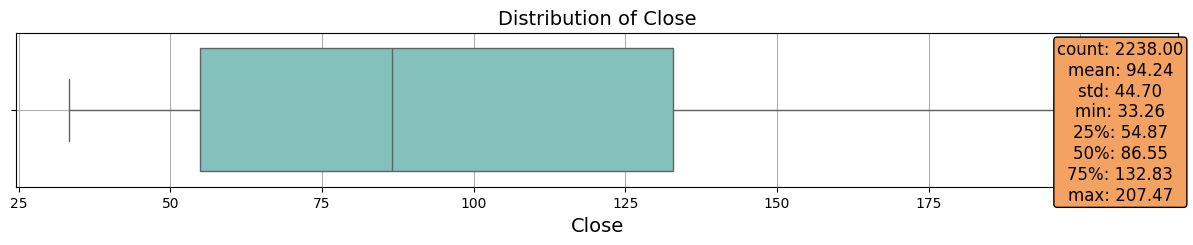

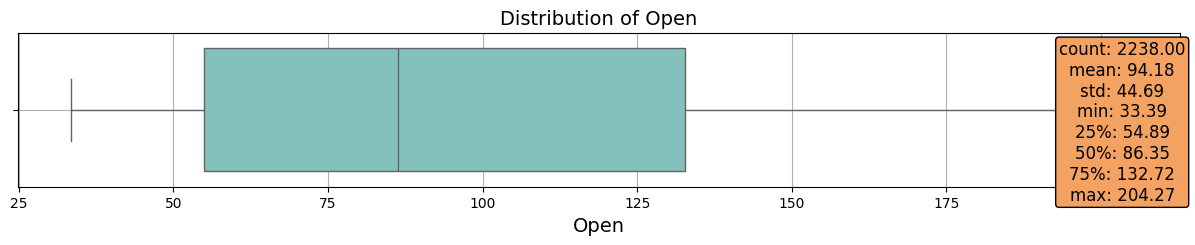

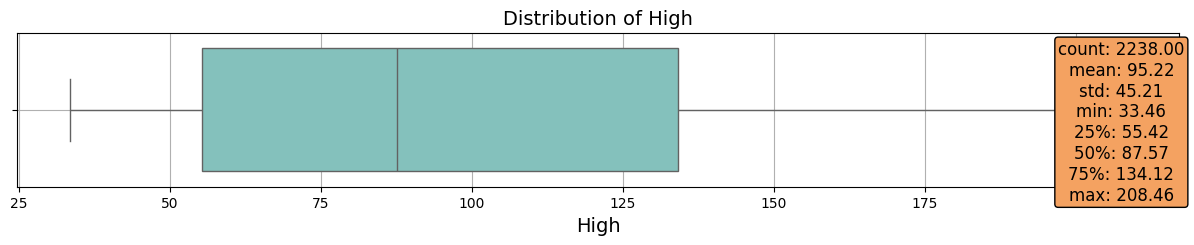

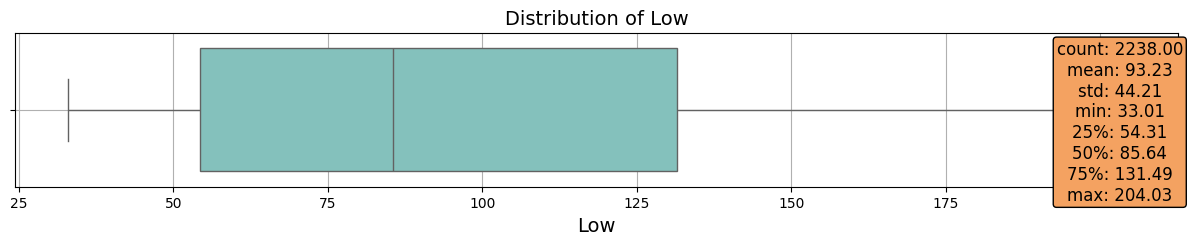

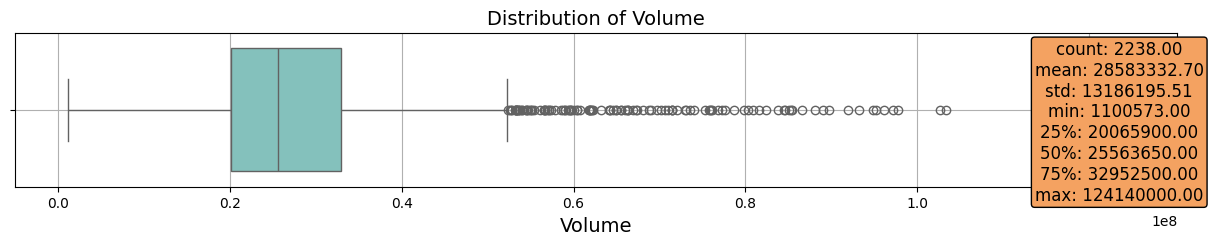

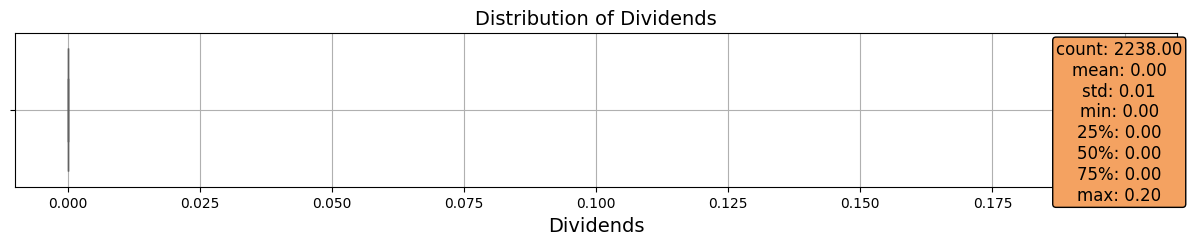

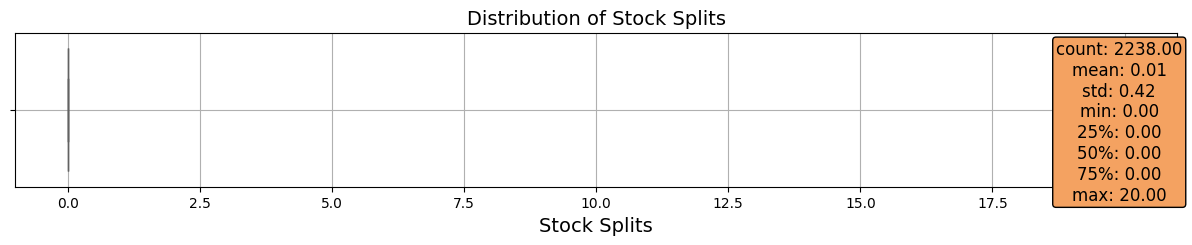

In [19]:
palette = "GnBu"
for column in df.columns:
    plt.figure(figsize=(15, 2))
    sns.boxplot(x=df[column], palette=palette)
    plt.title(f'Distribution of {column}', fontsize=14)
    plt.xlabel(column, fontsize=14)
    stats = df[column].describe()
    stats_text = "\n".join([f"{key}: {value:.2f}" for key, value in stats.items()])
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top',
             horizontalalignment='center', bbox=dict(boxstyle='round,pad=0.2', edgecolor='black', facecolor='#f4a261'))
    plt.grid(True)
    plt.show()

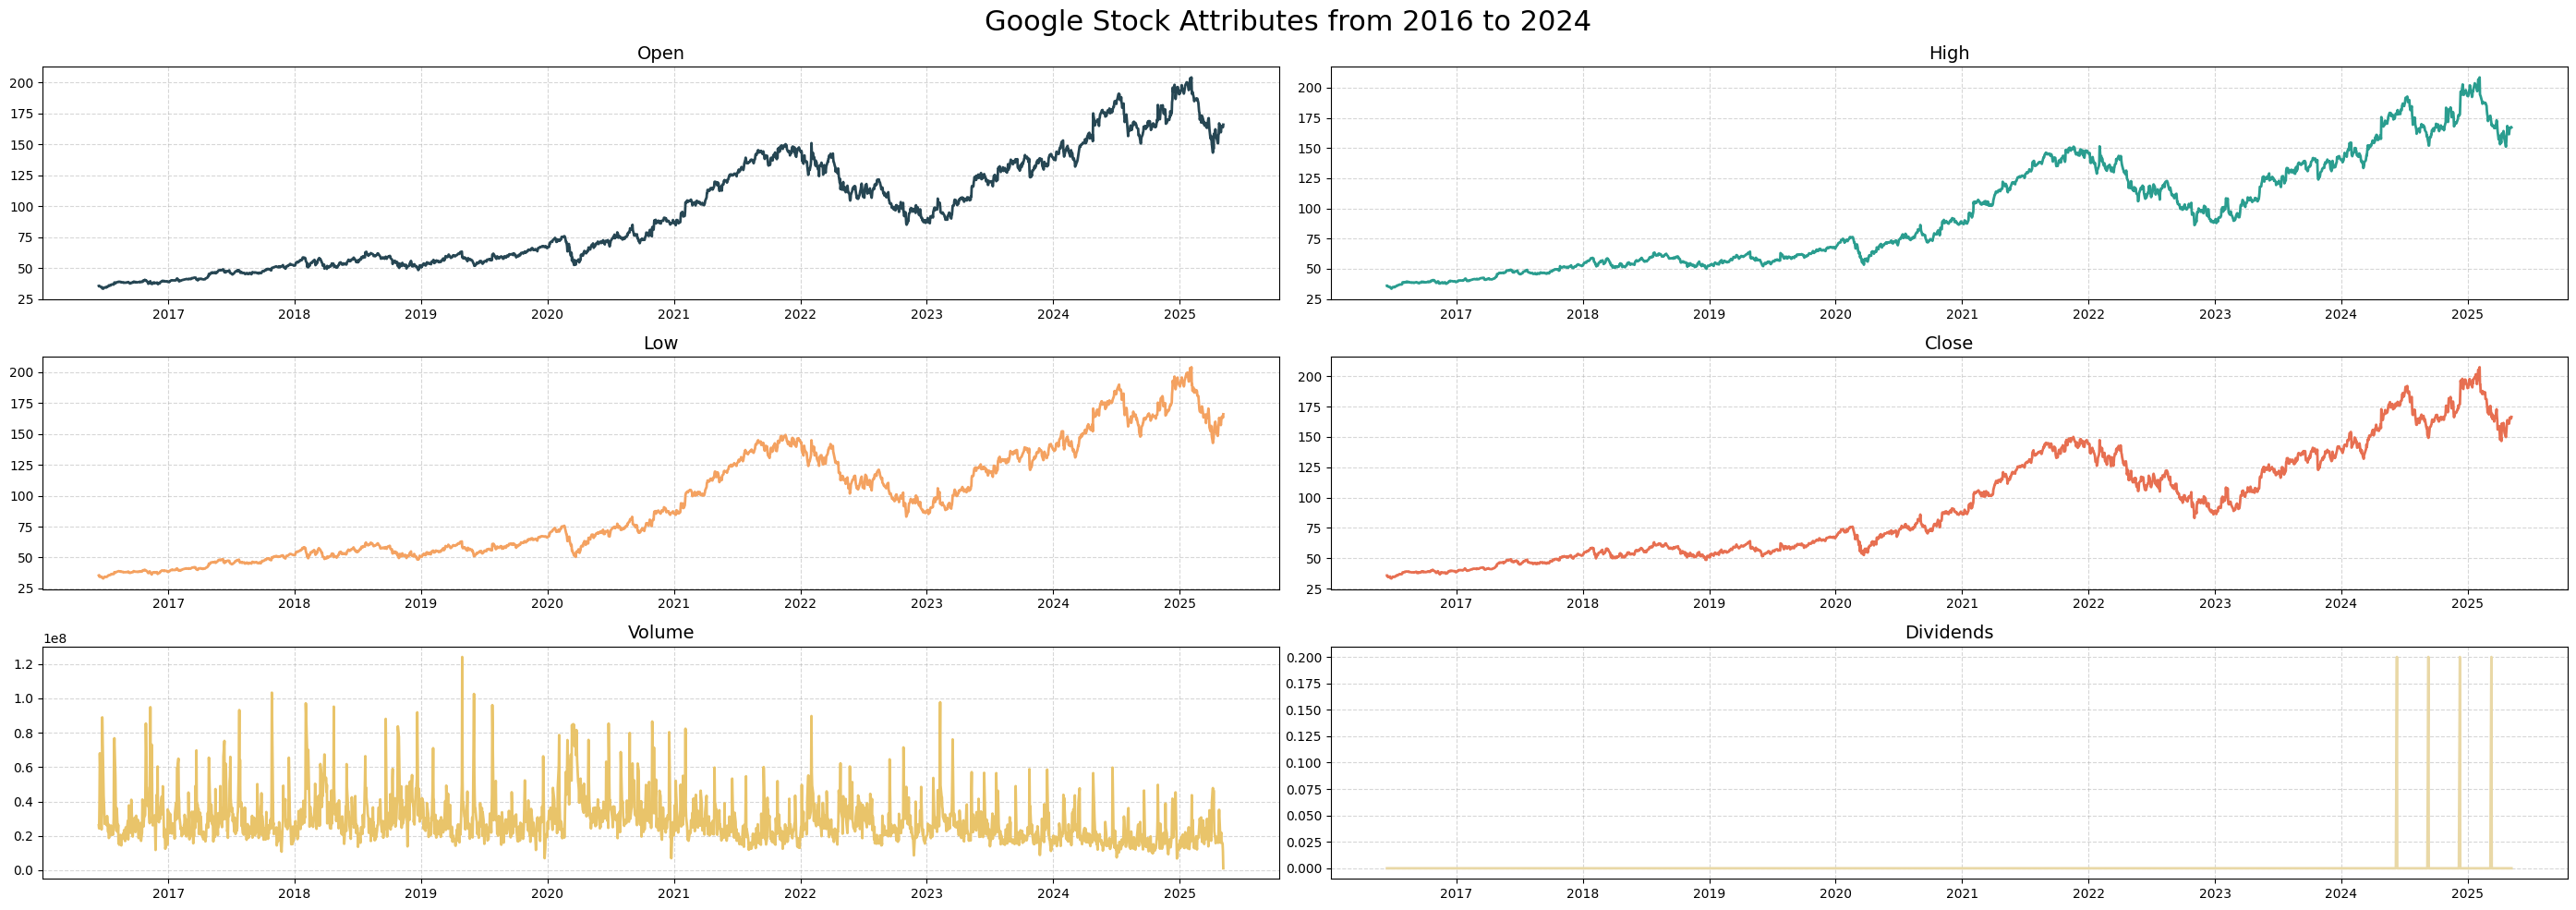

In [20]:
import matplotlib.pyplot as plt
x=df.index
colors = ['#264653', '#2a9d8f', '#f4a261', '#e76f51','#e9c46a', '#e9d8a6']
plt.figure(figsize=(28, 10))
plt.subplot(3, 2, 1)
plt.plot(x, df['Open'], color=colors[0], linewidth=2)
plt.title('Open', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.subplot(3, 2, 2)
plt.plot(x, df['High'], color=colors[1], linewidth=2)
plt.title('High', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.subplot(3, 2, 3)
plt.plot(x, df['Low'], color=colors[2], linewidth=2)
plt.title('Low', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.subplot(3, 2, 4)
plt.plot(x, df['Close'], color=colors[3], linewidth=2)
plt.title('Close', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.subplot(3, 2, 5)
plt.plot(x, df['Volume'], color=colors[4], linewidth=2)
plt.title('Volume', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.subplot(3, 2, 6)
plt.plot(x, df['Dividends'], color=colors[5], linewidth=2)
plt.title('Dividends', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.suptitle('Google Stock Attributes from 2016 to 2024', fontsize=22, y=0.98)
plt.tight_layout()
plt.show()

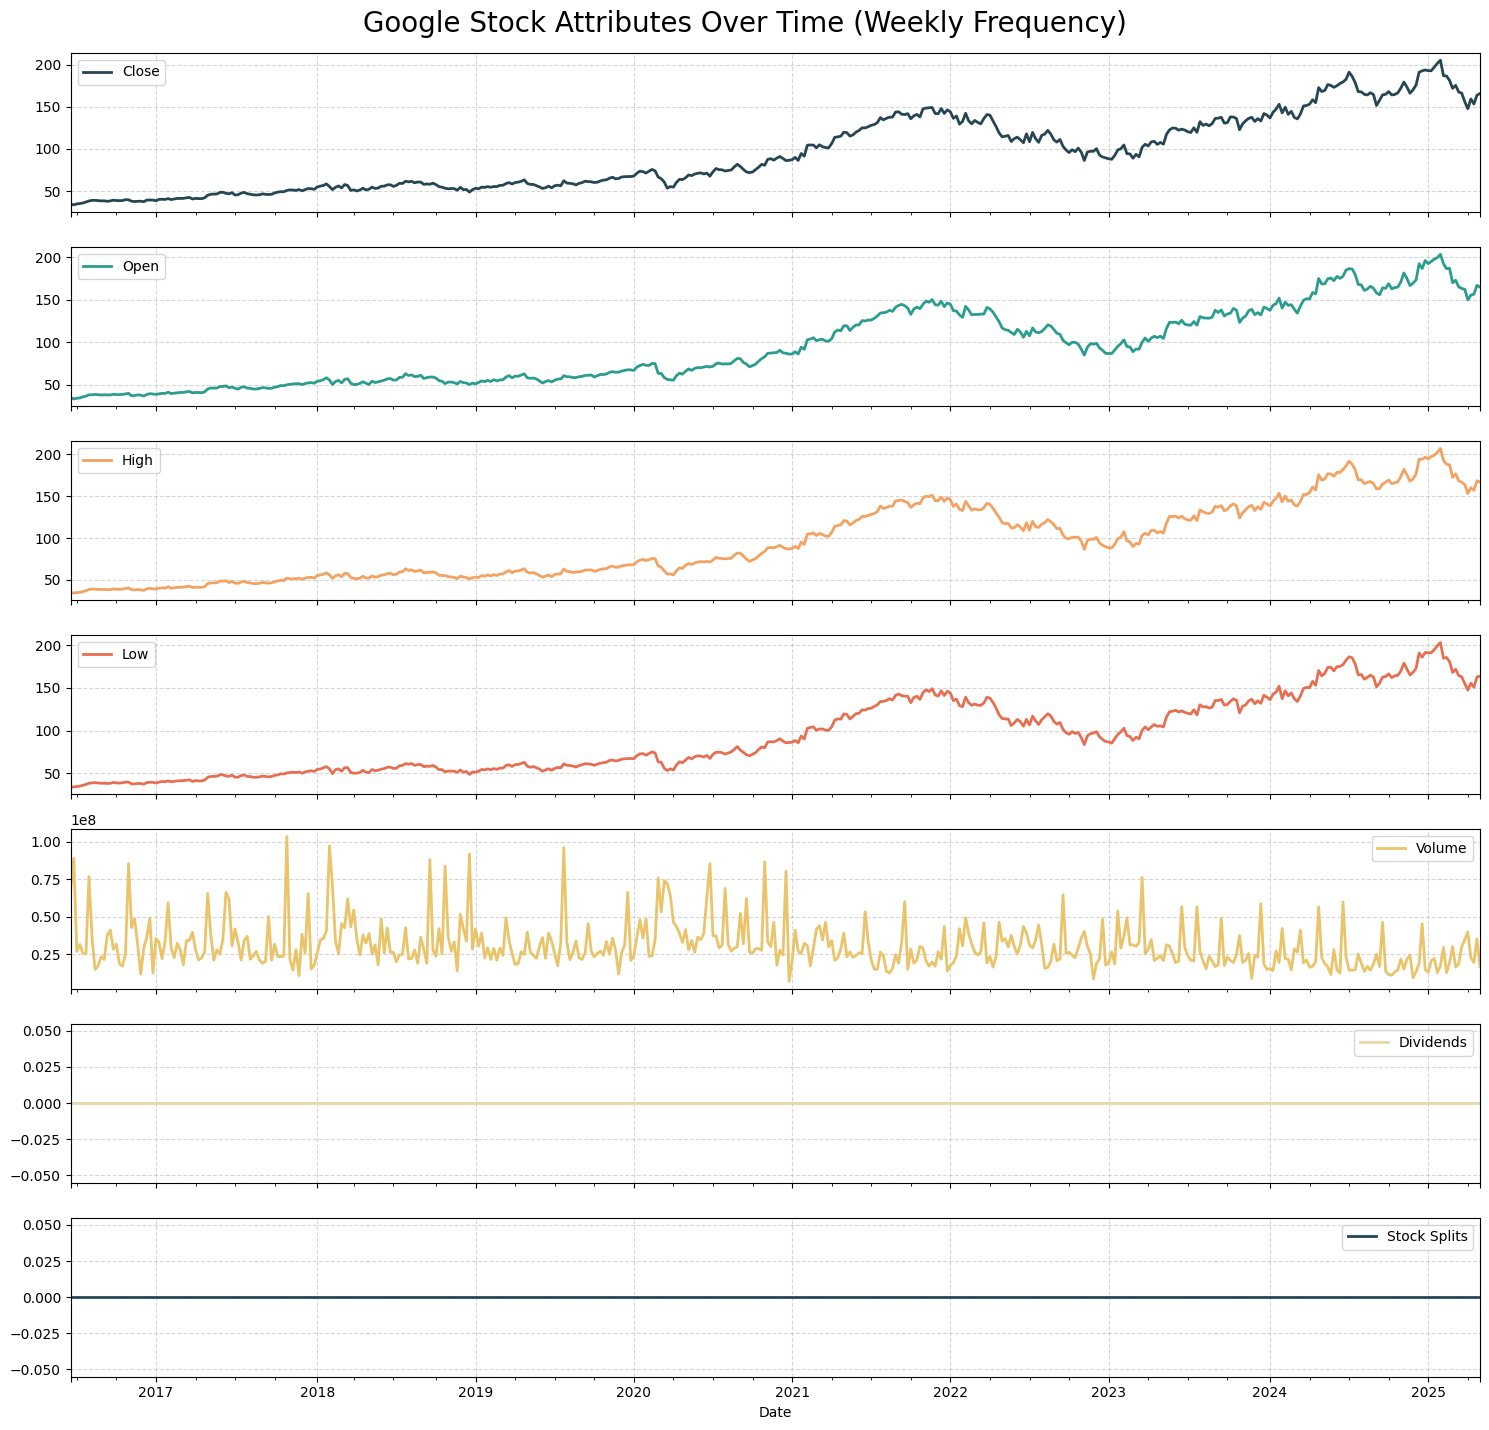

In [21]:
colors = ['#264653', '#2a9d8f', '#f4a261', '#e76f51', '#e9c46a', '#e9d8a6']
df_weekly = df.asfreq('W', method='ffill')
df_weekly.plot(subplots=True, figsize=(15, 15), style='-', color=colors, linewidth=2)
plt.suptitle('Google Stock Attributes Over Time (Weekly Frequency)', fontsize=20, y=0.95)
for ax in plt.gcf().get_axes():
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(ax.get_title(), fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

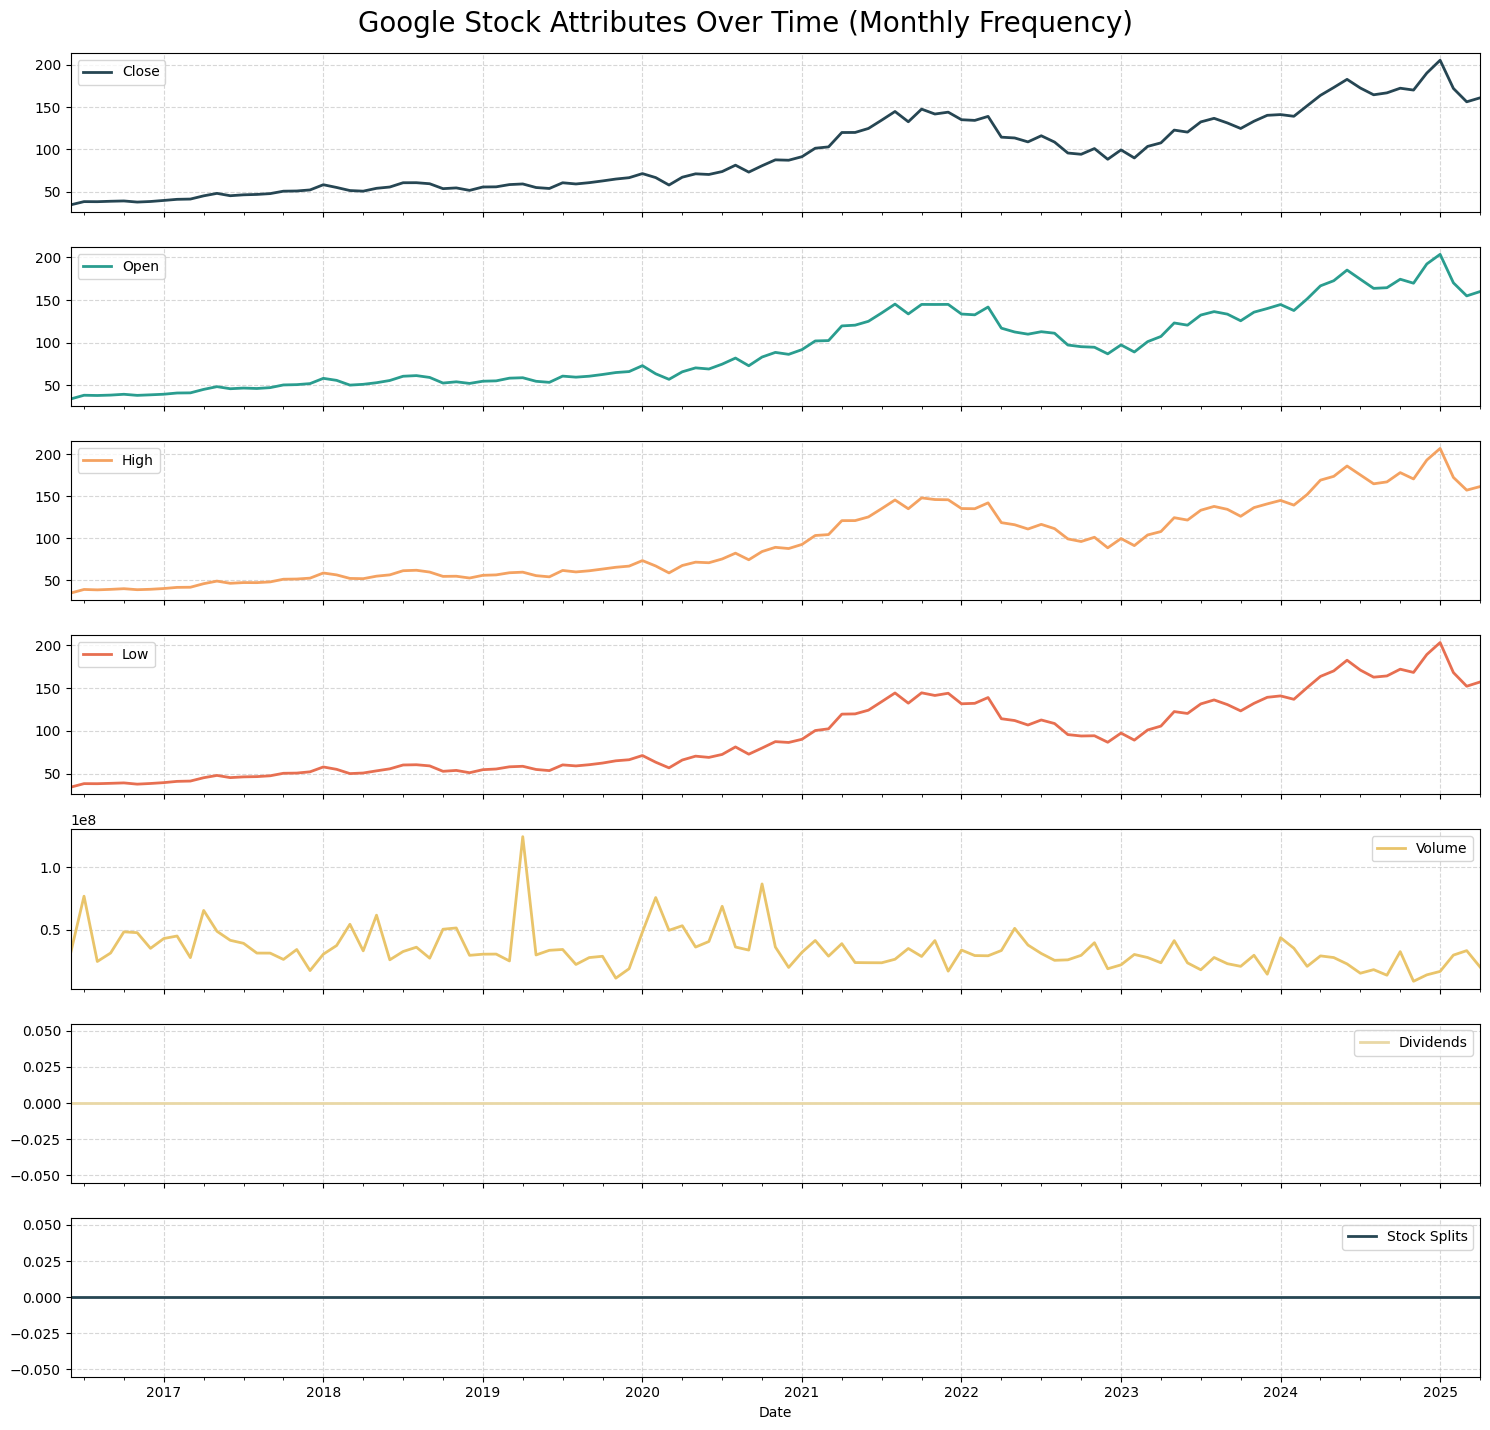

In [22]:
colors = ['#264653', '#2a9d8f', '#f4a261', '#e76f51', '#e9c46a', '#e9d8a6']
df_weekly = df.asfreq('M', method='ffill')
df_weekly.plot(subplots=True, figsize=(15, 15), style='-', color=colors, linewidth=2)
plt.suptitle('Google Stock Attributes Over Time (Monthly Frequency)', fontsize=20, y=0.95)
for ax in plt.gcf().get_axes():
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(ax.get_title(), fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [23]:
# trace for candlestick chart
candletrace = go.Candlestick(
    x=df.index,
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    name='Candlestick',
    increasing=dict(line=dict(color='#2a9d8f')),
    decreasing=dict(line=dict(color='#f4a261')))
# layout for the chart with custom colors
layout = go.Layout(
    title='GOOG Candlestick Chart',
    xaxis=dict(title='Date', color='#2a9d8f'),
    yaxis=dict(title='Price', color='#2a9d8f', rangemode='normal'),
    plot_bgcolor='rgba(0,0,0,0)',  # transparent background
    paper_bgcolor='rgba(255,255,255,0.85)')  # slight transparency on paper background)
# creating the figure
fig = go.Figure(data=[candletrace], layout=layout)
# removing the range slider and showing the figure
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

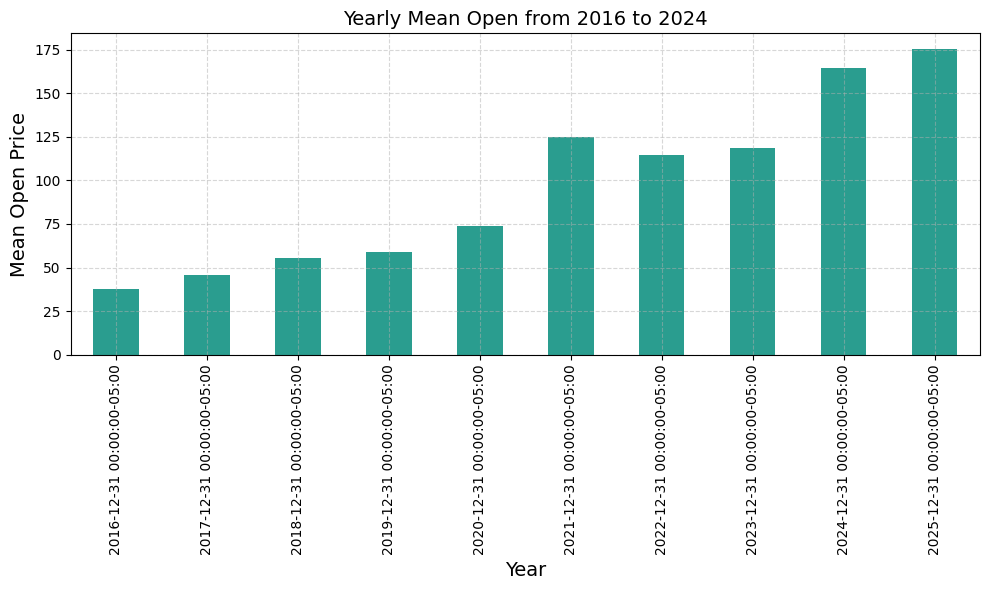

In [24]:
import math
import yfinance as yf
import datetime as dt
# Resampling the 'Open' data by year-end and plotting the mean values
plt.figure(figsize=(10, 6))  # Set figure size
df['Open'].resample('A').mean().plot(kind='bar', color='#2a9d8f')  # Updated color
plt.title('Yearly Mean Open from 2016 to 2024', fontsize=14)  # Title with larger font
plt.xlabel('Year', fontsize=14)  # X-axis label with larger font
plt.ylabel('Mean Open Price', fontsize=14)  # Y-axis label with larger font
plt.grid(True, linestyle='--', alpha=0.5)  # Grid with dashed lines
plt.tight_layout()  # Adjust layout to fit everything nicely
plt.show()

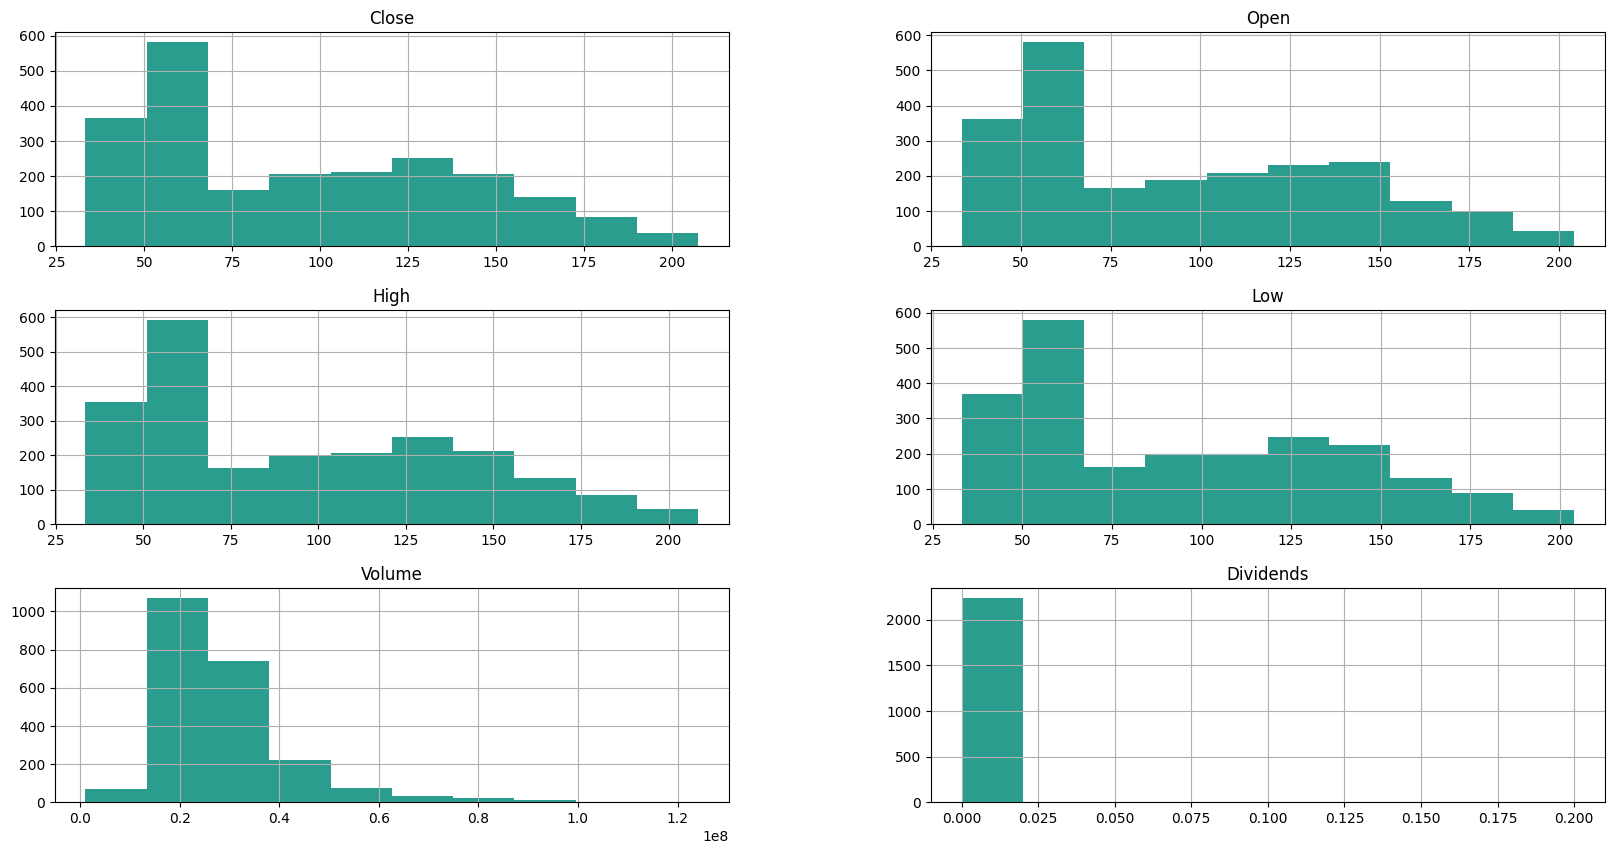

In [27]:
df1 = df.copy()
df1.drop("Stock Splits", axis=1, inplace=True)
fig = plt.figure(figsize = (20,10))
ax = fig.gca()
hist=df1.hist(ax = ax , color= '#2a9d8f')

In [28]:
df[['Close']]

,Close
Date,
2016-06-14 00:00:00-04:00,35.744198
2016-06-15 00:00:00-04:00,35.776546
2016-06-16 00:00:00-04:00,35.350563
2016-06-17 00:00:00-04:00,34.422955
2016-06-20 00:00:00-04:00,34.521988
...,...
2025-05-01 00:00:00-04:00,162.789993
2025-05-02 00:00:00-04:00,165.809998
2025-05-05 00:00:00-04:00,166.050003


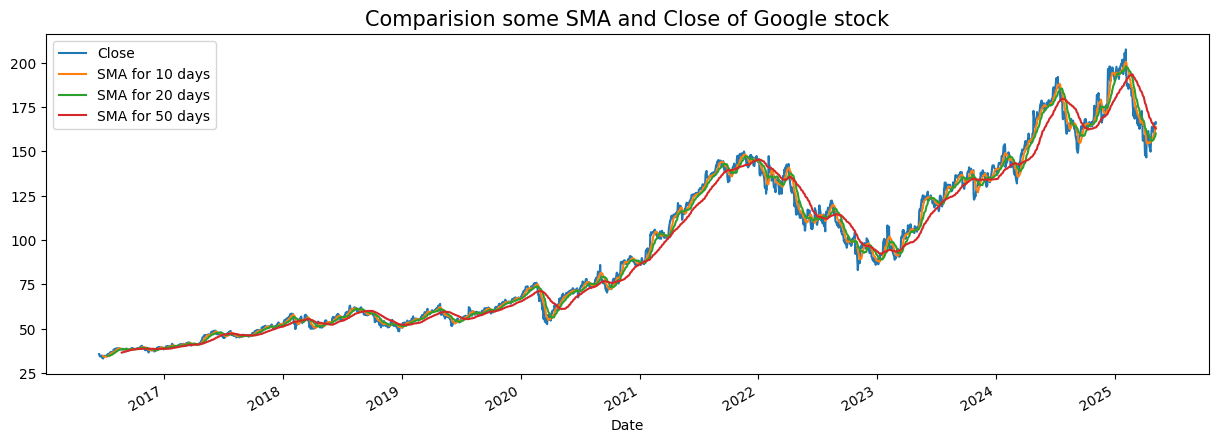

In [29]:
md = [10, 20, 50]
for SMA in md:
    col = f'SMA for {SMA} days'
    df[col] = df['Close'].rolling(SMA).mean()
df[['Close', 'SMA for 10 days', 'SMA for 20 days', 'SMA for 50 days']].plot(figsize=(15,5))
plt.title('Comparision some SMA and Close of Google stock', fontsize=15)
plt.show()

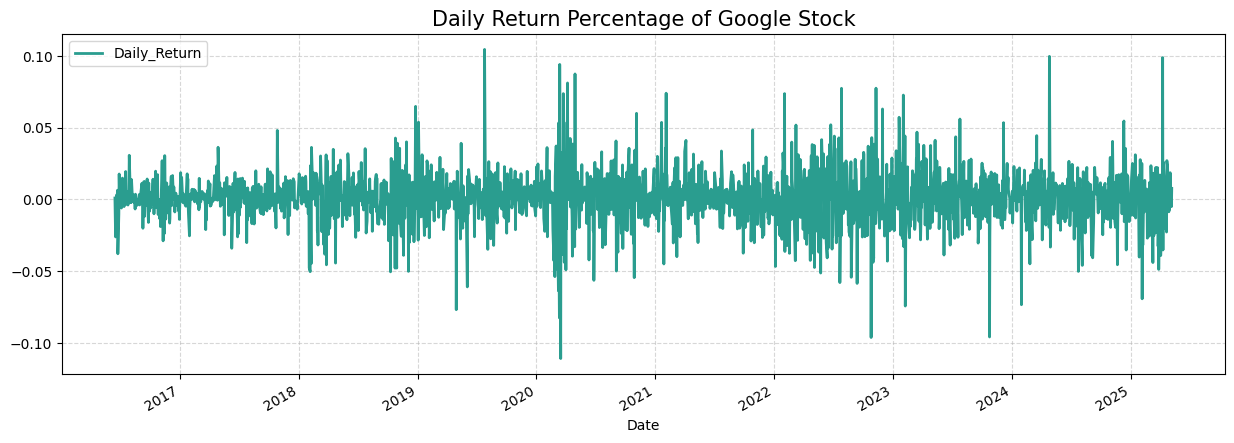

In [30]:
df['Daily_Return'] = df['Close'].pct_change()
df['Daily_Return'].plot(legend=True, figsize=(15, 5), color='#2a9d8f', linewidth=2)
plt.title('Daily Return Percentage of Google Stock', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [31]:
# Create a deep copy of the original dataframe
df2 = df.copy(deep=True)

# Initialize the MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))

# Apply scaling to each column individually
df2['Open'] = scaler.fit_transform(df2.Open.values.reshape(-1, 1))
df2['High'] = scaler.fit_transform(df2.High.values.reshape(-1, 1))
df2['Low'] = scaler.fit_transform(df2.Low.values.reshape(-1, 1))
df2['Close'] = scaler.fit_transform(df2.Close.values.reshape(-1, 1))
df2['Volume'] = scaler.fit_transform(df2.Volume.values.reshape(-1, 1))

# Select the relevant columns for further processing
df3 = df2[['Open', 'High', 'Low', 'Volume', 'Close']].values

# Output the shape of the resulting dataframe
df3.shape

(2238, 5)

In [32]:
seq_len = 11
sequence = []
for index in range(len(df3) - seq_len + 1):
    sequence.append(df3[index: index + seq_len])
sequence = np.array(sequence)
print(sequence.shape)

(2228, 11, 5)


In [33]:
def split_data(sequence):
    train_data, test_data = train_test_split(sequence, test_size=0.2, shuffle=False)
    val_data, test_data = train_test_split(test_data, test_size=0.5, shuffle=False)
    return train_data, val_data, test_data

In [34]:
train_data, val_data, test_data = split_data(sequence)
print("Train:", train_data.shape, "Validation:", val_data.shape, "Test:", test_data.shape)

Train: (1782, 11, 5) Validation: (223, 11, 5) Test: (223, 11, 5)


In [35]:
x_train = train_data[:, :-1, :]
y_train = train_data[:, -1, -1]
x_valid = val_data[:, :-1, :]
y_valid = val_data[:, -1, -1]
x_test = test_data[:, :-1, :]
y_test = test_data[:, -1, -1]
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_valid shape: {x_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (1782, 10, 5)
y_train shape: (1782,)
x_valid shape: (223, 10, 5)
y_valid shape: (223,)
x_test shape: (223, 10, 5)
y_test shape: (223,)


In [36]:
model_lstm = Sequential()
model_lstm.add(LSTM(units=64, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model_lstm.add(LSTM(units=32, return_sequences=False))
model_lstm.add(Dense(units=25))
model_lstm.add(Dense(units=1))

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model_lstm.fit(x_train, y_train, epochs=50, batch_size=32,
                       validation_data=(x_valid, y_valid))

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0750 - val_loss: 0.0044
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0016 - val_loss: 0.0060
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - val_loss: 0.0069
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0012 - val_loss: 0.0067
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0012 - val_loss: 0.0056
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0012 - val_loss: 0.0057
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0011 - val_loss: 0.0054
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0010 - val_loss: 0.0046
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0012 - val_loss: 0.0033
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - val_loss: 0.0032
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0010 - val_loss: 0.0028
Epoch 12/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0

In [37]:
# Predict on the test data
y_pred = model_lstm.predict(x_test)

# Evaluate the predictions
test_loss = model_lstm.evaluate(x_test, y_test)
print("Test Loss:", test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0021 
Test Loss: 0.0023511091712862253


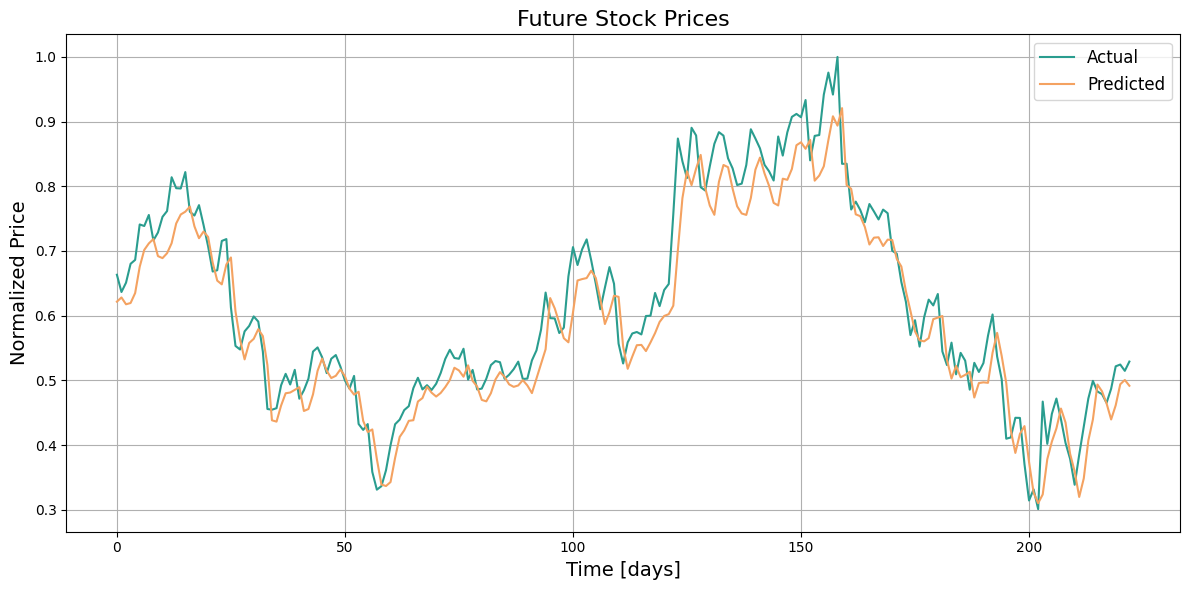

In [38]:
plt.figure(figsize=(12, 6))
idx = 0
plt.plot(y_test, color='#2a9d8f', label='Actual')
plt.plot(y_pred, color='#f4a261', label='Predicted')
plt.title('Future Stock Prices', fontsize=16)
plt.xlabel('Time [days]', fontsize=14)
plt.ylabel('Normalized Price', fontsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid()
plt.tight_layout()
plt.show()

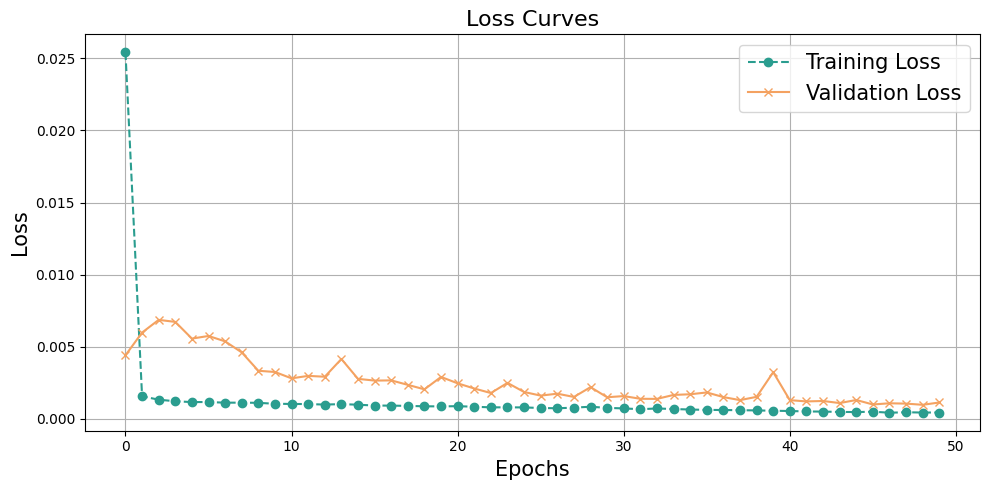

In [39]:
# Plotting the loss curves
def plot_loss_curve(history):
    plt.figure(figsize=(10, 5))

    # Loss curve
    plt.plot(history.history['loss'], label='Training Loss', color='#2a9d8f', marker='o', linestyle='--')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='#f4a261', marker='x', linestyle='-')

    plt.title('Loss Curves', fontsize=16)
    plt.xlabel('Epochs', fontsize=15)
    plt.ylabel('Loss', fontsize=15)
    plt.legend(fontsize=15)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call the function to plot the loss curve
plot_loss_curve(history)

In [40]:
print("### Model Summary ###")
model_lstm.summary()

### Model Summary ###


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │           825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,563 (365.48 KB)

 Trainable params: 31,187 (121.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,376 (243.66 KB)

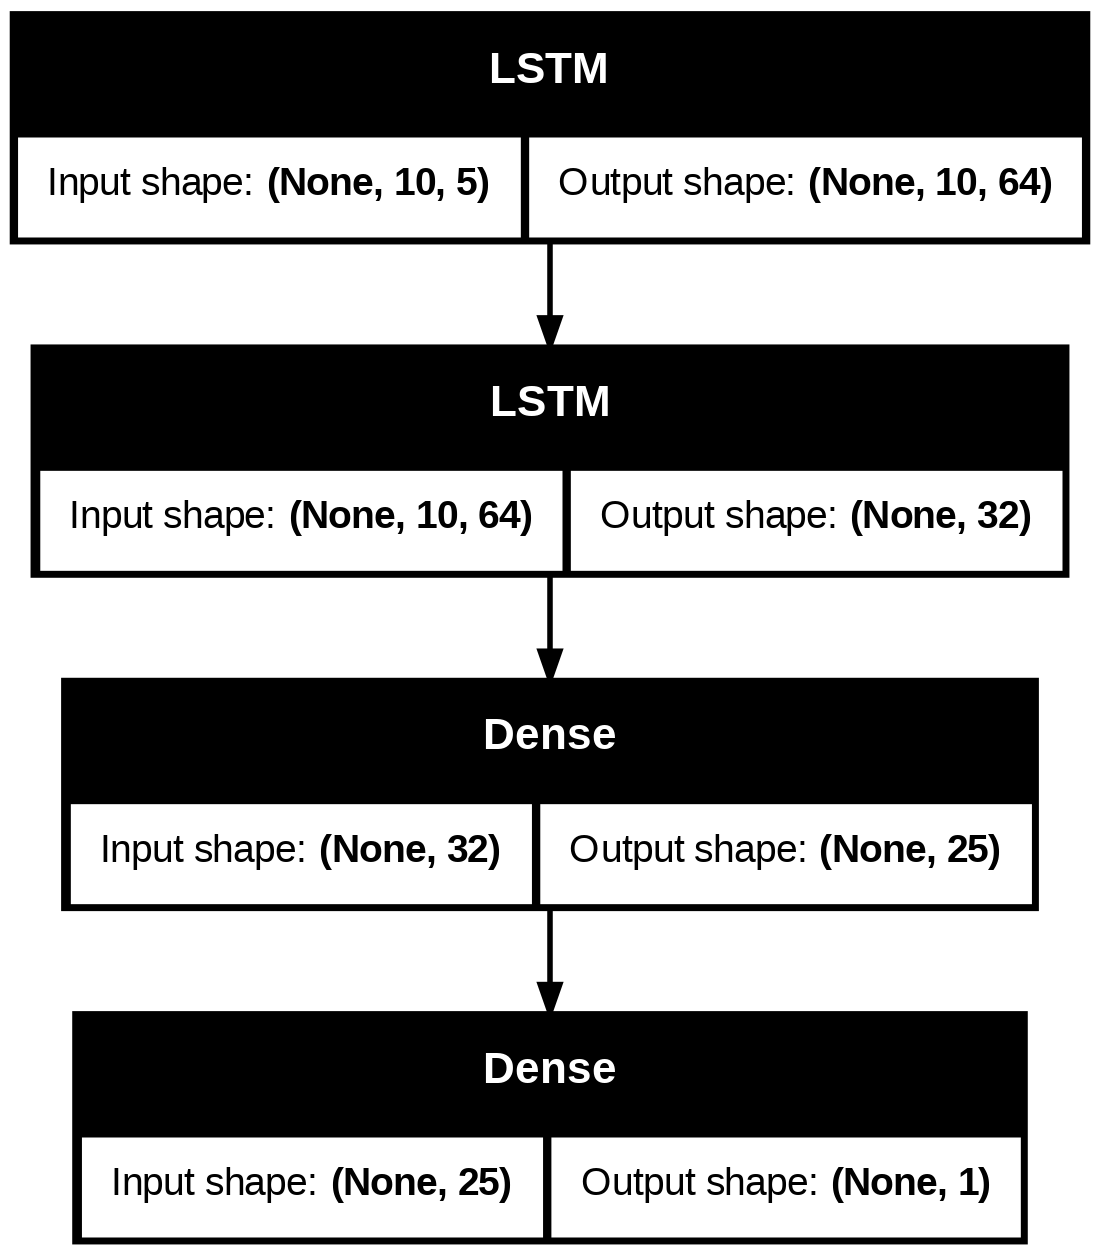

In [41]:
# Save the model architecture as an image
plot_model(model_lstm, to_file='model_architecture.png', show_shapes=True)

# Display the saved model architecture image
Image(filename='model_architecture.png')

In [42]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.8 MB/s eta 0:00:00


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


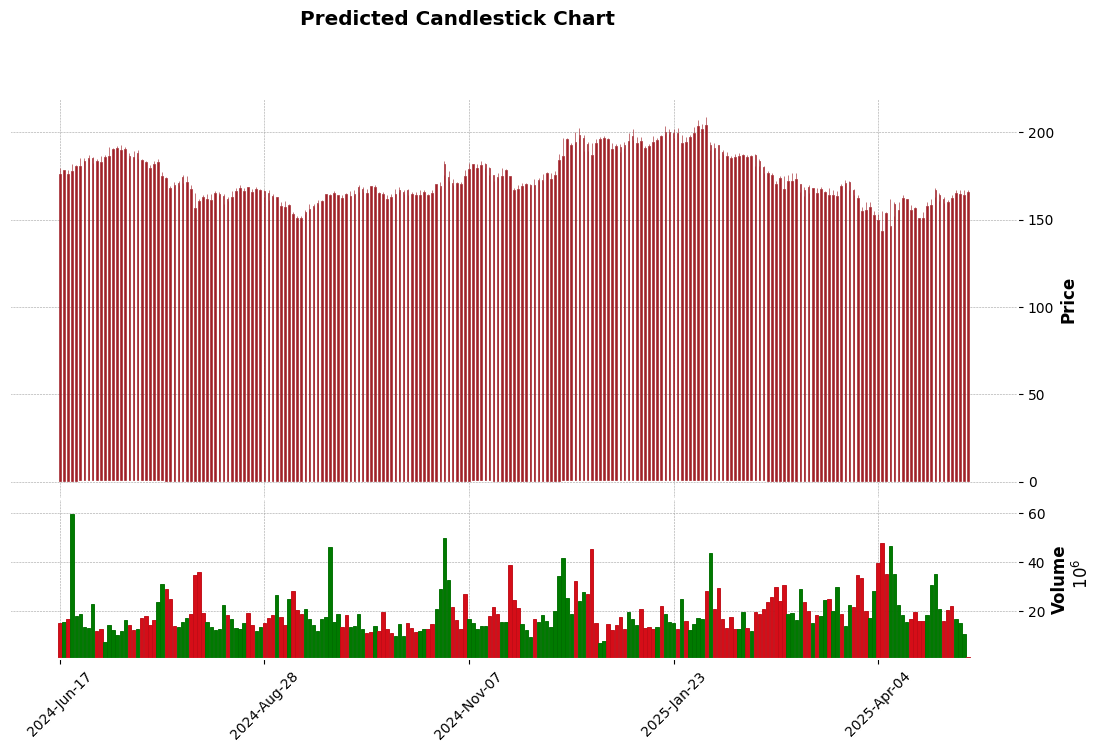

In [43]:
import mplfinance as mpf
predicted_prices = model_lstm.predict(x_test)
predicted_df = df.iloc[-len(predicted_prices):].copy()
predicted_df['Predicted Close'] = predicted_prices
predicted_df['Open'] = predicted_df['Open']
predicted_df['High'] = predicted_df['High']
predicted_df['Low'] = predicted_df['Low']
predicted_df['Close'] = predicted_df['Predicted Close']
final_df = predicted_df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
final_df.index = pd.to_datetime(predicted_df.index)
mpf.plot(
    final_df,
    type='candle',
    volume=True,
    style='charles',
    title="Predicted Candlestick Chart",
    ylabel="Price",
    ylabel_lower="Volume",
    figsize=(14, 8)
)

In [44]:
df = df.reset_index()  # This will move the index (Date) into a regular column.

In [45]:
# Assume df contains the main data with daily prices.
# Example data setup:
# df = pd.DataFrame({
#     'Open': [...],
#     'High': [...],
#     'Low': [...],
#     'Close': [...],
# })

# Ensure the DataFrame is ordered correctly
df['Date'] = pd.to_datetime(df['Date'])  # Assuming there is a column named Date
df.set_index('Date', inplace=True)

# Select prices for the candlestick
final_df = df[['Open', 'High', 'Low', 'Close']]

# Create the candlestick chart
candlestick_trace = go.Candlestick(
    x=final_df.index,
    open=final_df['Open'],
    high=final_df['High'],
    low=final_df['Low'],
    close=final_df['Close'],
    name='Candlestick',
    increasing_line_color='#2a9d8f',  # Color for increasing candles
    decreasing_line_color='#f4a261',    # Color for decreasing candles
)

# Create the figure
fig = go.Figure(data=[candlestick_trace])

# Add title and labels
fig.update_layout(
    title='Predicted Candlestick Chart',
    xaxis_title='Date',
    yaxis_title='Price',
    xaxis_rangeslider_visible=False,  # Disable the range slider below the chart
    template='plotly_white',            # Use a light template
    height=600,                         # Height of the chart
    width=1000                          # Width of the chart
)

# Show the chart
fig.show()


In [46]:
# Predicting the next 10 days
latest_prediction = []
last_seq = x_test[:-1]

for _ in range(10):
    prediction = model_lstm.predict(last_seq)
    latest_prediction.append(prediction)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [47]:
df = df.reset_index()  # This will move the index (Date) into a regular column.


In [48]:
predicted_data_next = np.array(latest_prediction).reshape(-1, 5)
last_date = df['Date'].max()
next_10_days = [last_date + timedelta(days=i) for i in range(1, 11)]

# Iterate over all features
for i, feature_name in enumerate(['Open', 'High', 'Low', 'Volume', 'Close']):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=next_10_days,
        y=predicted_data_next[:, i],
        mode='lines+markers',
        name=f'Predicted {feature_name.capitalize()} Prices',
        line=dict(color='#f4a261'),
        marker=dict(color='#f4a261')
    ))

    fig.update_layout(
        title=f'Predicted {feature_name.capitalize()} Prices for the Next 10 Days',
        xaxis_title='Date',
        yaxis_title=f'{feature_name.capitalize()} Price',
        plot_bgcolor='white'
    )

    fig.show()

In [49]:
tck = yf.Ticker("GOOG")
# defining the start date
start_date = "2016-06-14"
# historical data
df5 = tck.history(start=start_date, end=None)
df5

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-06-14 00:00:00-04:00,35.655123,35.953211,35.487912,35.744202,26122000,0.0,0.0
2016-06-15 00:00:00-04:00,35.780525,35.978585,35.696424,35.776543,24290000,0.0,0.0
2016-06-16 00:00:00-04:00,35.576992,35.663583,34.997237,35.350567,39650000,0.0,0.0
2016-06-17 00:00:00-04:00,35.265468,35.273931,34.260330,34.422958,68048000,0.0,0.0
2016-06-20 00:00:00-04:00,34.773794,34.958420,34.507059,34.521988,41650000,0.0,0.0
...,...,...,...,...,...,...,...
2025-05-01 00:00:00-04:00,162.520004,163.940002,160.929993,162.789993,21904300,0.0,0.0
2025-05-02 00:00:00-04:00,164.955002,166.699997,163.660004,165.809998,16844900,0.0,0.0
2025-05-05 00:00:00-04:00,164.514999,167.100006,164.470001,166.050003,15309300,0.0,0.0


In [50]:
df5 = df5.reset_index()  # This will move the index (Date) into a regular column.

In [51]:
df5['Volume'] = df5['Volume'].astype('float64')

In [52]:
sma_days = [10, 20, 50]
# Calculate SMAs for each window size and add them to the dataframe
for sma in sma_days:
    col_name = f'SMA_{sma}days'
    df5[col_name] = df5['Close'].rolling(sma).mean()

In [53]:
df5['SMA_10days'] = df5['SMA_10days'].fillna(df5['Close'])
df5['SMA_20days'] = df5['SMA_20days'].fillna(df5['Close'])
df5['SMA_50days'] = df5['SMA_50days'].fillna(df5['Close'])

df5.head(15)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_10days,SMA_20days,SMA_50days
0,2016-06-14 00:00:00-04:00,35.655123,35.953211,35.487912,35.744202,26122000.0,0.0,0.0,35.744202,35.744202,35.744202
1,2016-06-15 00:00:00-04:00,35.780525,35.978585,35.696424,35.776543,24290000.0,0.0,0.0,35.776543,35.776543,35.776543
2,2016-06-16 00:00:00-04:00,35.576992,35.663583,34.997237,35.350567,39650000.0,0.0,0.0,35.350567,35.350567,35.350567
3,2016-06-17 00:00:00-04:00,35.265468,35.273931,34.260330,34.422958,68048000.0,0.0,0.0,34.422958,34.422958,34.422958
4,2016-06-20 00:00:00-04:00,34.773794,34.958420,34.507059,34.521988,41650000.0,0.0,0.0,34.521988,34.521988,34.521988
5,2016-06-21 00:00:00-04:00,34.755379,34.972851,34.437385,34.632961,29312000.0,0.0,0.0,34.632961,34.632961,34.632961
6,2016-06-22 00:00:00-04:00,34.788228,34.877804,34.490736,34.708607,23686000.0,0.0,0.0,34.708607,34.708607,34.708607
7,2016-06-23 00:00:00-04:00,34.708111,34.932049,34.188071,34.928066,43428000.0,0.0,0.0,34.928066,34.928066,34.928066
8,2016-06-24 00:00:00-04:00,33.599358,34.307506,33.513765,33.601849,88980000.0,0.0,0.0,33.601849,33.601849,33.601849
9,2016-06-27 00:00:00-04:00,33.391841,33.456537,33.007860,33.255486,52580000.0,0.0,0.0,34.694323,33.255486,33.255486


In [54]:
ten_days = df5[['Open','High','Low', 'Volume','SMA_10days','Close']].copy(deep=True)
twenty_days = df5[['Open','High','Low', 'Volume','SMA_20days','Close']].copy(deep=True)
all_sma = df5[['Open','High','Low', 'Volume','SMA_10days','SMA_20days','Close']].copy(deep=True)

In [55]:
# Scaling

# 10 days SMA
scaler = MinMaxScaler(feature_range=(0,2)).fit(ten_days.Low.values.reshape(-1,1))
ten_days['Open'] = scaler.transform(ten_days.Open.values.reshape(-1,1))
ten_days['High'] = scaler.transform(ten_days.High.values.reshape(-1,1))
ten_days['Low'] = scaler.transform(ten_days.Low.values.reshape(-1,1))
ten_days['Volume'] = scaler.transform(ten_days.Volume.values.reshape(-1,1))
ten_days['Close'] = scaler.transform(ten_days.Close.values.reshape(-1,1))
ten_days['SMA_10days'] = scaler.transform(ten_days['SMA_10days'].values.reshape(-1,1))

# 20 days SMA
scaler = MinMaxScaler(feature_range=(0,2)).fit(twenty_days.Low.values.reshape(-1,1))
twenty_days['Open'] = scaler.transform(twenty_days.Open.values.reshape(-1,1))
twenty_days['High'] = scaler.transform(twenty_days.High.values.reshape(-1,1))
twenty_days['Low'] = scaler.transform(twenty_days.Low.values.reshape(-1,1))
twenty_days['Volume'] = scaler.transform(twenty_days.Volume.values.reshape(-1,1))
twenty_days['Close'] = scaler.transform(twenty_days.Close.values.reshape(-1,1))
twenty_days['SMA_20days'] = scaler.transform(twenty_days['SMA_20days'].values.reshape(-1,1))

# Both 10 & 20 days SMA
scaler = MinMaxScaler(feature_range=(0,2)).fit(all_sma.Low.values.reshape(-1,1))
all_sma['Open'] = scaler.transform(all_sma.Open.values.reshape(-1,1))
all_sma['High'] = scaler.transform(all_sma.High.values.reshape(-1,1))
all_sma['Low'] = scaler.transform(all_sma.Low.values.reshape(-1,1))
all_sma['Volume'] = scaler.transform(all_sma.Volume.values.reshape(-1,1))
all_sma['Close'] = scaler.transform(all_sma.Close.values.reshape(-1,1))
all_sma['SMA_10days'] = scaler.transform(all_sma['SMA_10days'].values.reshape(-1,1))
all_sma['SMA_20days'] = scaler.transform(all_sma['SMA_20days'].values.reshape(-1,1))

In [56]:
# rescaled dataframes
data_10days = ten_days[['Open','High','Low', 'SMA_10days','Close']].values
data_20days = twenty_days[['Open','High','Low','SMA_20days','Close']].values
data_all = all_sma[['Open','High','Low', 'SMA_10days','SMA_20days','Close']].values

In [57]:
print(data_10days.shape)
print(data_20days.shape)
print(data_all.shape)

(2238, 5)
(2238, 5)
(2238, 6)


In [58]:
# using the price of the previous 10 days to predict the next day price
seq_len = 11

# 10 days SMA sequence
sequence_10days = []
for index in range(len(data_10days) - seq_len + 1):
    sequence_10days.append(data_10days[index: index + seq_len])
sequence_10days = np.array(sequence_10days)
print(sequence_10days.shape)

# 20 days SMA sequence
sequence_20days = []
for index in range(len(data_20days) - seq_len + 1):
    sequence_20days.append(data_20days[index: index + seq_len])
sequence_20days = np.array(sequence_20days)
print(sequence_20days.shape)

# Both SMAs sequence
sequence_all = []
for index in range(len(data_all) - seq_len + 1):
    sequence_all.append(data_all[index: index + seq_len])
sequence_all = np.array(sequence_all)
print(sequence_all.shape)

(2228, 11, 5)
(2228, 11, 5)
(2228, 11, 6)


In [59]:
# split data
train_data_10days, val_data_10days, test_data_10days = split_data(sequence_10days)
train_data_20days, val_data_20days, test_data_20days = split_data(sequence_20days)
train_data_all, val_data_all, test_data_all = split_data(sequence_all)

In [60]:
ORANGE = "\033[38;5;214m"
RESET = "\033[0m"

# Check shapes of the split data
print(f"{ORANGE}Shapes:\n{RESET}")
print(f"{ORANGE}10 days SMA sequence:{RESET}")
print(f"{ORANGE}Train:{RESET} {train_data_10days.shape} {ORANGE}Validation:{RESET} {val_data_10days.shape} {ORANGE}Test:{RESET} {test_data_10days.shape}")
print(f"{ORANGE}20 days SMA sequence:{RESET}")
print(f"{ORANGE}Train:{RESET} {train_data_20days.shape} {ORANGE}Validation:{RESET} {val_data_20days.shape} {ORANGE}Test:{RESET} {test_data_20days.shape}")
print(f"{ORANGE}Both SMAs sequence:{RESET}")
print(f"{ORANGE}Train:{RESET} {train_data_all.shape} {ORANGE}Validation:{RESET} {val_data_all.shape} {ORANGE}Test:{RESET} {test_data_all.shape}")

Shapes:

10 days SMA sequence:
Train: (1782, 11, 5) Validation: (223, 11, 5) Test: (223, 11, 5)
20 days SMA sequence:
Train: (1782, 11, 5) Validation: (223, 11, 5) Test: (223, 11, 5)
Both SMAs sequence:
Train: (1782, 11, 6) Validation: (223, 11, 6) Test: (223, 11, 6)


In [61]:
# Split X and Y for each dataset
def split_Xy(dataset):
    # Extract features (X) and target (Y)
    X = dataset[:, :-1, :]
    Y = dataset[:, -1, -1]   #last column (close price)
    return X, Y
# Split X and Y for each dataset
x_train_10d, y_train_10d = split_Xy(train_data_10days)
x_val_10d, y_val_10d = split_Xy(val_data_10days)
x_test_10d, y_test_10d = split_Xy(test_data_10days)
x_train_20d, y_train_20d = split_Xy(train_data_20days)
x_val_20d, y_val_20d = split_Xy(val_data_20days)
x_test_20d, y_test_20d = split_Xy(test_data_20days)
x_train_all, y_train_all = split_Xy(train_data_all)
x_val_all, y_val_all = split_Xy(val_data_all)
x_test_all, y_test_all = split_Xy(test_data_all)
print(x_train_10d.shape, y_train_10d.shape)
print(x_val_10d.shape, y_val_10d.shape)

(1782, 10, 5) (1782,)
(223, 10, 5) (223,)


In [62]:
# dataloader

batch_size = 64
# 10 days SMA
x_train_10d = torch.tensor(x_train_10d).float()
y_train_10d = torch.tensor(y_train_10d).float()
x_val_10d = torch.tensor(x_val_10d).float()
y_val_10d = torch.tensor(y_val_10d).float()
train_set_10d = TensorDataset(x_train_10d,y_train_10d)
train_dataloader_10d = DataLoader(train_set_10d, batch_size=32, shuffle=False)
val_set_10d = TensorDataset(x_val_10d ,y_val_10d)
val_dataloader_10d = DataLoader(val_set_10d, batch_size=32, shuffle=False)


# 20 days SMA
x_train_20d = torch.tensor(x_train_20d).float()
y_train_20d = torch.tensor(y_train_20d).float()
x_val_20d = torch.tensor(x_val_20d).float()
y_val_20d = torch.tensor(y_val_20d).float()
train_set_20d = TensorDataset(x_train_20d,y_train_20d)
train_dataloader_20d = DataLoader(train_set_20d, batch_size=32, shuffle=False)
val_set_20d = TensorDataset(x_val_20d, y_val_20d)
val_dataloader_20d = DataLoader(val_set_20d, batch_size=32, shuffle=False)

# 10 & 20 days SMA
x_train_all = torch.tensor(x_train_all).float()
y_train_all = torch.tensor(y_train_all).float()
x_val_all = torch.tensor(x_val_all).float()
y_val_all = torch.tensor(y_val_all).float()
train_set_all = TensorDataset(x_train_all,y_train_all)
train_dataloader_all = DataLoader(train_set_all, batch_size=32, shuffle=False)
val_set_all = TensorDataset(x_val_all,y_val_all)
val_dataloader_all = DataLoader(val_set_all, batch_size=32, shuffle=False)

In [63]:
class NeuralNetwork(nn.Module):
    def __init__(self, num_feature):
        super(NeuralNetwork, self).__init__()
        self.lstm = nn.LSTM(num_feature, 64, batch_first=True)  # 64 represents the number of hidden units in the LSTM layer
        self.dropout = nn.Dropout(p=0.5)  # Adding Dropout layer with a dropout probability of 0.5
        self.fc = nn.Linear(64, num_feature)

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)
        x = self.dropout(hidden[-1])  # Apply dropout to the last hidden state
        x = self.fc(x)
        return x

mse = nn.MSELoss()
epochs = 50

In [64]:
def train(model, dataloader, optimizer, criterion):
    model.train()
    epoch_loss = 0

    for inputs, target in dataloader:
        optimizer.zero_grad()
        # Forward pass
        prediction = model(inputs)
        target = target.unsqueeze(-1)  # Reshape target to match prediction shape
        loss = criterion(prediction, target)  # Calculate the loss

        loss.backward()  # Backward pass
        optimizer.step()  # Optimize

        epoch_loss += loss.item()

    return epoch_loss

In [65]:
def evaluate(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for inputs, target in dataloader:
            prediction = model(inputs)
            target = target.unsqueeze(-1)  # Reshape target to match prediction shape
            loss = criterion(prediction, target)  # Calculate the loss

            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

Model architecture saved as 'model_lstm.png'.


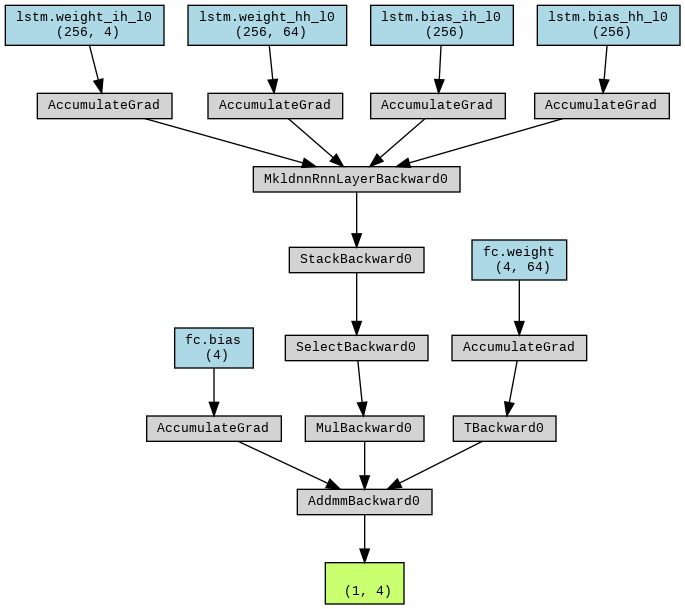

In [66]:
# Create the model instance
num_feature = 4  # Adjust this according to your features
model = NeuralNetwork(num_feature)

# Push to CUDA if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Generate a random input tensor
x = torch.randn(1, 10, num_feature).to(device)  # (batch_size, sequence_length, num_features)

# Visualize the model architecture using torchviz
try:
    y = model(x)  # Forward pass to generate graph
    graph = make_dot(y, params=dict(model.named_parameters()))
    graph.render("model_lstm", format="png")  # Save as PNG
    print("Model architecture saved as 'model_lstm.png'.")

    # Display the saved image in the Jupyter Notebook
    display(Image(filename="model_lstm.png"))
except Exception as e:
    print(f"Error plotting model architecture: {e}")

In [67]:
model_10d = NeuralNetwork(5)
optimizer = optim.Adam(model_10d.parameters())

In [68]:
train_losses = []
valid_losses = []

for epoch in range(1, epochs + 1):
    # Training
    train_loss = train(model_10d, train_dataloader_10d, optimizer, mse)
    train_losses.append(train_loss)

    # Validation
    valid_loss = evaluate(model_10d, val_dataloader_10d, mse)
    valid_losses.append(valid_loss)

    # Print epoch statistics
    print(f'Epoch [{epoch}/{epochs}], Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}')

Epoch [1/50], Train Loss: 1.8269, Valid Loss: 0.2489
Epoch [2/50], Train Loss: 3.5779, Valid Loss: 0.1892
Epoch [3/50], Train Loss: 3.3454, Valid Loss: 0.0309
Epoch [4/50], Train Loss: 2.2973, Valid Loss: 0.0365
Epoch [5/50], Train Loss: 1.5143, Valid Loss: 0.0320
Epoch [6/50], Train Loss: 1.0998, Valid Loss: 0.0321
Epoch [7/50], Train Loss: 1.0575, Valid Loss: 0.0398
Epoch [8/50], Train Loss: 1.0766, Valid Loss: 0.0170
Epoch [9/50], Train Loss: 0.9402, Valid Loss: 0.0202
Epoch [10/50], Train Loss: 0.7317, Valid Loss: 0.0196
Epoch [11/50], Train Loss: 0.7110, Valid Loss: 0.0130
Epoch [12/50], Train Loss: 0.6606, Valid Loss: 0.0108
Epoch [13/50], Train Loss: 0.5692, Valid Loss: 0.0142
Epoch [14/50], Train Loss: 0.6012, Valid Loss: 0.0176
Epoch [15/50], Train Loss: 0.5926, Valid Loss: 0.0183
Epoch [16/50], Train Loss: 0.5769, Valid Loss: 0.0119
Epoch [17/50], Train Loss: 0.5431, Valid Loss: 0.0088
Epoch [18/50], Train Loss: 0.5217, Valid Loss: 0.0098
Epoch [19/50], Train Loss: 0.5804, Va

In [69]:
x_test_10d = torch.tensor(x_test_10d).float()
y_test_10d = torch.tensor(y_test_10d).float()

# Predict on the test data
with torch.no_grad():
    y_pred_10d = model_10d(x_test_10d)

# Convert predictions and actual test data to numpy arrays
y_pred_10d = y_pred_10d.numpy()
y_test_10d = y_test_10d.numpy()

# Reshape and select last element from prediction (closing price)
y_pred_10d = y_pred_10d.reshape(-1, y_pred_10d.shape[-1])[:, -1]

In [70]:
model_20d = NeuralNetwork(5)
optimizer = optim.Adam(model_20d.parameters())

In [71]:
train_losses = []
valid_losses = []

for epoch in range(1, epochs + 1):
    # Training
    train_loss = train(model_20d, train_dataloader_20d, optimizer, mse)
    train_losses.append(train_loss)

    # Validation
    valid_loss = evaluate(model_20d, val_dataloader_20d, mse)
    valid_losses.append(valid_loss)

    # Print epoch statistics
    print(f'Epoch [{epoch}/{epochs}], Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}')

Epoch [1/50], Train Loss: 1.9023, Valid Loss: 0.2516
Epoch [2/50], Train Loss: 3.0463, Valid Loss: 0.1979
Epoch [3/50], Train Loss: 3.2177, Valid Loss: 0.0470
Epoch [4/50], Train Loss: 2.4661, Valid Loss: 0.0371
Epoch [5/50], Train Loss: 1.7663, Valid Loss: 0.0314
Epoch [6/50], Train Loss: 1.1343, Valid Loss: 0.0346
Epoch [7/50], Train Loss: 0.9839, Valid Loss: 0.0328
Epoch [8/50], Train Loss: 0.9586, Valid Loss: 0.0270
Epoch [9/50], Train Loss: 0.9957, Valid Loss: 0.0302
Epoch [10/50], Train Loss: 0.8665, Valid Loss: 0.0255
Epoch [11/50], Train Loss: 0.7813, Valid Loss: 0.0206
Epoch [12/50], Train Loss: 0.7508, Valid Loss: 0.0151
Epoch [13/50], Train Loss: 0.7762, Valid Loss: 0.0142
Epoch [14/50], Train Loss: 0.6544, Valid Loss: 0.0173
Epoch [15/50], Train Loss: 0.7215, Valid Loss: 0.0131
Epoch [16/50], Train Loss: 0.6339, Valid Loss: 0.0096
Epoch [17/50], Train Loss: 0.5822, Valid Loss: 0.0083
Epoch [18/50], Train Loss: 0.5464, Valid Loss: 0.0099
Epoch [19/50], Train Loss: 0.5453, Va

In [72]:
x_test_20d = torch.tensor(x_test_20d).float()
y_test_20d = torch.tensor(y_test_20d).float()

# Predict on the test data
with torch.no_grad():
    y_pred_20d = model_20d(x_test_20d)

# Convert predictions and actual test data to numpy arrays
y_pred_20d = y_pred_20d.numpy()
y_test_20d = y_test_20d.numpy()

# Reshape and select last element from prediction (closing price)
y_pred_20d = y_pred_20d.reshape(-1, y_pred_20d.shape[-1])[:, -1]

In [73]:
model_all = NeuralNetwork(6)
optimizer = optim.Adam(model_all.parameters())

In [75]:
epochs=100
train_losses = []
valid_losses = []

for epoch in range(1, epochs + 1):
    # Training
    train_loss = train(model_all, train_dataloader_all, optimizer, mse)
    train_losses.append(train_loss)

    # Validation
    valid_loss = evaluate(model_all, val_dataloader_all, mse)
    valid_losses.append(valid_loss)

    # Print epoch statistics
    print(f'Epoch [{epoch}/{epochs}], Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}')

Epoch [1/100], Train Loss: 1.7599, Valid Loss: 0.2807
Epoch [2/100], Train Loss: 3.3816, Valid Loss: 0.1841
Epoch [3/100], Train Loss: 3.3237, Valid Loss: 0.0328
Epoch [4/100], Train Loss: 2.1510, Valid Loss: 0.0373
Epoch [5/100], Train Loss: 1.4043, Valid Loss: 0.0276
Epoch [6/100], Train Loss: 1.1042, Valid Loss: 0.0279
Epoch [7/100], Train Loss: 0.9958, Valid Loss: 0.0248
Epoch [8/100], Train Loss: 0.9710, Valid Loss: 0.0222
Epoch [9/100], Train Loss: 0.8143, Valid Loss: 0.0206
Epoch [10/100], Train Loss: 0.7738, Valid Loss: 0.0158
Epoch [11/100], Train Loss: 0.6869, Valid Loss: 0.0140
Epoch [12/100], Train Loss: 0.6825, Valid Loss: 0.0152
Epoch [13/100], Train Loss: 0.6313, Valid Loss: 0.0163
Epoch [14/100], Train Loss: 0.6695, Valid Loss: 0.0143
Epoch [15/100], Train Loss: 0.6042, Valid Loss: 0.0127
Epoch [16/100], Train Loss: 0.5629, Valid Loss: 0.0138
Epoch [17/100], Train Loss: 0.5832, Valid Loss: 0.0075
Epoch [18/100], Train Loss: 0.5248, Valid Loss: 0.0142
Epoch [19/100], Tra

In [76]:
x_test_all = torch.tensor(x_test_all).float()
y_test_all = torch.tensor(y_test_all).float()

# predict on the test data
with torch.no_grad():
    y_pred_all = model_all(x_test_all)

y_pred_all = y_pred_all.numpy()
y_test_all = y_test_all.numpy()

# reshape & select last element from prediction (closing price)
y_pred_all = y_pred_all.reshape(-1, y_pred_all.shape[-1])[:, -1]

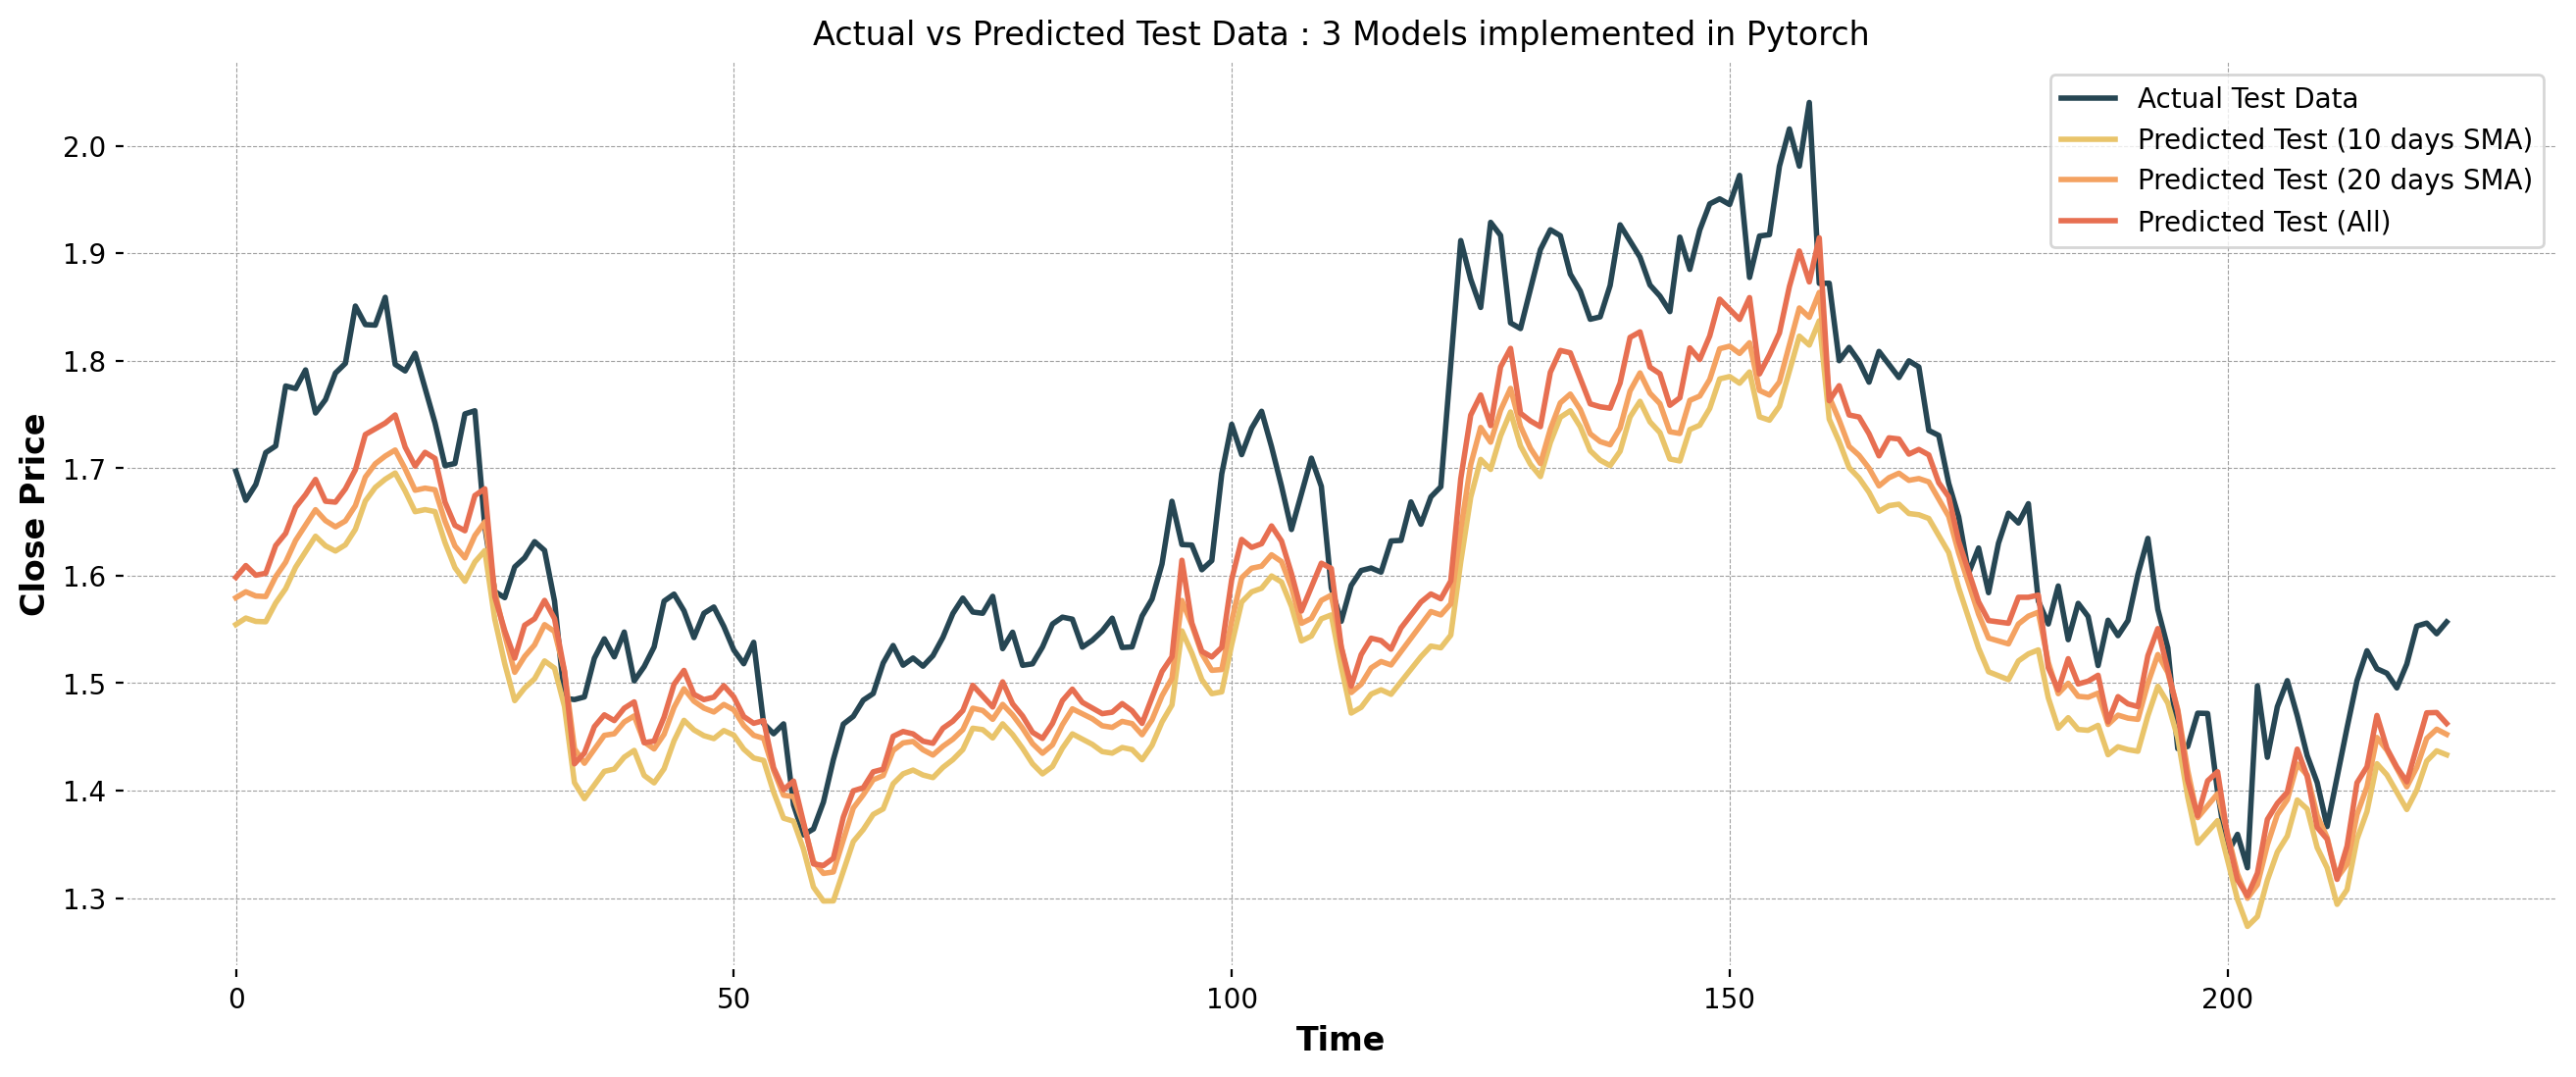

In [77]:
plt.figure(figsize=(16,6), dpi=200)

plt.plot(y_test_10d, label='Actual Test Data', color='#264653')
plt.plot(y_pred_10d, label='Predicted Test (10 days SMA)', color='#e9c46a')
plt.plot(y_pred_20d, label='Predicted Test (20 days SMA)', color='#f4a261')
plt.plot(y_pred_all, label='Predicted Test (All)', color='#e76f51')

plt.title('Actual vs Predicted Test Data : 3 Models implemented in Pytorch')
plt.xlabel('Time')
plt.ylabel('Close Price')

plt.legend()
plt.show()

In [78]:
# Get the last sequence of data as features for predicting the next 10 days
last_sequence = sequence_all[-1:, :, :]
last_sequence = torch.from_numpy(last_sequence).float()

# Generate predictions for the next 10 days
days_num = 10
with torch.no_grad():
    for i in range(days_num):
        pred = model_all(last_sequence)  # This should be of shape (1, 1, features)

        # Reshape pred to match the dimensions of last_sequence for concatenation
        pred = pred.unsqueeze(1)  # Add sequence length dimension (1, 1, features)

        last_sequence = torch.cat((last_sequence, pred), dim=1)  # Concatenate along sequence length
        last_sequence = last_sequence[:, 1:, :]  # Keep the last sequence length of data

# Convert predictions to numpy array
predicting_days = last_sequence.squeeze().numpy()

# Inverse transform the predicted values
predicting_days = scaler.inverse_transform(predicting_days)

# Extract relevant features (Open, High, Low, Close)
predicting_days = predicting_days[:days_num, :4]

# Create a DataFrame to store the predicted prices
df_pred = pd.DataFrame(
    data=predicting_days,
    columns=['Open', 'High', 'Low', 'Close']
)

# Get the last date in the main DataFrame
last_date_in_df = df['Date'].iloc[-1]

# Generate dates for the next 10 days after the last date in the main DataFrame
next_dates = pd.date_range(start=last_date_in_df + pd.Timedelta(days=1), periods=days_num)

# Create a DataFrame with the dates
df_dates = pd.DataFrame({'Date': next_dates})

# Concatenate the two DataFrames
df_combined = pd.concat([df_dates, df_pred], axis=1)

print(df_combined)

                       Date        Open        High         Low       Close
0 2025-05-08 00:00:00-04:00  166.059998  166.979996  165.610001  163.667999
1 2025-05-09 00:00:00-04:00  159.589081  159.596176  159.616425  159.598709
2 2025-05-10 00:00:00-04:00  153.052338  153.059784  153.078125  153.062805
3 2025-05-11 00:00:00-04:00  146.025314  146.030334  146.046738  146.034851
4 2025-05-12 00:00:00-04:00  139.328644  139.332092  139.346283  139.337341
5 2025-05-13 00:00:00-04:00  133.173859  133.176437  133.188721  133.181915
6 2025-05-14 00:00:00-04:00  127.653610  127.655785  127.666565  127.661217
7 2025-05-15 00:00:00-04:00  122.795425  122.797508  122.807167  122.802734
8 2025-05-16 00:00:00-04:00  118.589294  118.591423  118.600311  118.596413
9 2025-05-17 00:00:00-04:00  114.999710  115.001938  115.010330  115.006668
